<div style="background: linear-gradient(135deg, #1a472a, #2d5a27); padding: 40px; border-radius: 12px; text-align: center; color: white;">
  <h1 style="font-size: 2.4em; margin: 0;">⚽ European Football Analytics</h1>
  <h2 style="font-weight: 300; margin: 10px 0 0 0; font-size: 1.2em;">2025–2026 Season · Top 5 Leagues · Player Statistics</h2>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 20px 0;">
  <p style="margin: 0; opacity: 0.85;">Data Science Internship Project &nbsp;|&nbsp; Decode Labs &nbsp;|&nbsp; Intern: Mohamed Mamdouh</p>
</div>

---

## Project Overview

Complete end-to-end football analytics across all 5 internship tasks — analyzing **2,779 players** from the 2025/26 season. This version includes **20 professional visualizations** uncovering advanced hidden insights, and **5 machine learning models** (1 role classifier + 4 position-specific regression models).

| Task | Title | Deliverable |
|------|-------|-------------|
| 1 | Data Collection & Dataset Understanding | Structure, schema, football context |
| 2 | Data Cleaning & Preprocessing | Clean dataset, engineered features |
| 3 | Exploratory Data Analysis | Deep positional & league insights |
| 4 | Data Visualization | **20 professional charts** |
| 5 | Predictive Modeling | **Role classifier + 4 position models** |

---
# 🗂️ TASK 1 — Data Collection & Dataset Understanding

> **Goal:** Load the dataset, understand its structure, and document every column before any analysis begins.

In professional data science you never jump straight into analysis. You understand the data first — what columns exist, what they mean, how big the data is, and where the gaps are.

In [1]:
# ── Import all required libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# ── Global chart style ──
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'axes.titlesize'    : 14,
    'axes.labelsize'    : 11,
})

# ── Color palettes — matching original notebook ──
LEAGUE_COLORS = {
    'Premier League' : '#01ef78',
    'Bundesliga'     : '#b20018',
    'La Liga'        : '#ff9a27',
    'Serie A'        : '#1d7cdb',
    'Ligue 1'        : '#002654',
}
POS_COLORS = {
    'FW': '#c80000',
    'MF': '#005aa8',
    'DF': '#4ebb05',
    'GK': '#e1fa00',
}

os.makedirs('../visuals', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

def save_fig(name):
    plt.savefig(f'../visuals/{name}', bbox_inches='tight', dpi=150)
    print(f'   💾 Saved → visuals/{name}')

print('✅ Libraries imported.')
print(f'   League colors : {list(LEAGUE_COLORS.keys())}')
print(f'   Position colors: {list(POS_COLORS.keys())}')

✅ Libraries imported.
   League colors : ['Premier League', 'Bundesliga', 'La Liga', 'Serie A', 'Ligue 1']
   Position colors: ['FW', 'MF', 'DF', 'GK']


In [2]:
df_raw = pd.read_csv('../data/players_data-2025_2026.csv')
print(f'📐 Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\n📋 All columns:')
for i, col in enumerate(df_raw.columns, 1):
    print(f'   {i:>3}. {col}')

📐 Shape: 2,839 rows × 102 columns

📋 All columns:
     1. Rk
     2. Player
     3. Nation
     4. Pos
     5. Squad
     6. Comp
     7. Age
     8. Born
     9. MP
    10. Starts
    11. Min
    12. 90s
    13. Gls
    14. Ast
    15. G+A
    16. G-PK
    17. PK
    18. PKatt
    19. CrdY
    20. CrdR
    21. G+A-PK
    22. Rk_stats_keeper
    23. Nation_stats_keeper
    24. Pos_stats_keeper
    25. Comp_stats_keeper
    26. Age_stats_keeper
    27. Born_stats_keeper
    28. MP_stats_keeper
    29. Starts_stats_keeper
    30. Min_stats_keeper
    31. 90s_stats_keeper
    32. GA
    33. GA90
    34. SoTA
    35. Saves
    36. Save%
    37. W
    38. D
    39. L
    40. CS
    41. CS%
    42. PKatt_stats_keeper
    43. PKA
    44. PKsv
    45. PKm
    46. Rk_stats_shooting
    47. Nation_stats_shooting
    48. Pos_stats_shooting
    49. Comp_stats_shooting
    50. Age_stats_shooting
    51. Born_stats_shooting
    52. 90s_stats_shooting
    53. Gls_stats_shooting
    54. Sh
    55. SoT

In [6]:
schema = {
    'Player Identity'  : ['Player','Nation','Pos','Squad','Comp','Age','Born'],
    'Playing Time'     : ['MP','Starts','Min','90s'],
    'Attacking'        : ['Gls','Ast','G+A','G-PK','PK','PKatt','G+A-PK'],
    'Shooting'         : ['Sh','SoT','SoT%','Sh/90','SoT/90','G/Sh','G/SoT'],
    'Discipline'       : ['CrdY','CrdR','2CrdY','Fls','Fld','OG'],
    'Defending'        : ['TklW','Int','Crs'],
    'Goalkeeping'      : ['GA','GA90','SoTA','Saves','Save%','W','D','L','CS','CS%','PKA','PKsv','PKm'],
    'Playing Time Adv' : ['Mn/MP','Min%','Mn/Start','Compl','Subs','Mn/Sub','unSub',
                          'PPM','onG','onGA','+/-','+/-90','On-Off'],
}
print('╔════════════════════════════════════╗')
print('║       DATASET COLUMN SCHEMA        ║')
print('╠════════════════════════════════════╣')
for cat, cols in schema.items():
    print(f'║  {cat:<22} {len(cols):>2} columns ║')
print('╚════════════════════════════════════╝')
df_raw[['Player','Pos','Squad','Comp','Age','Gls','Ast','Sh','TklW','Int']].head(4)

╔════════════════════════════════════╗
║       DATASET COLUMN SCHEMA        ║
╠════════════════════════════════════╣
║  Player Identity         7 columns ║
║  Playing Time            4 columns ║
║  Attacking               7 columns ║
║  Shooting                7 columns ║
║  Discipline              6 columns ║
║  Defending               3 columns ║
║  Goalkeeping            13 columns ║
║  Playing Time Adv       13 columns ║
╚════════════════════════════════════╝


,Player,Pos,Squad,Comp,Age,Gls,Ast,Sh,TklW,Int
0,Brenden Aaronson,"MF,FW",Leeds United,eng Premier League,25.0,4,5,47,27,17
1,Jerome Abbey,MF,Wolves,eng Premier League,16.0,0,0,0,0,1
2,Zach Abbott,DF,Nottingham Forest,eng Premier League,20.0,0,0,0,4,2
3,Jones El-Abdellaoui,"MF,FW",Celta Vigo,es La Liga,20.0,2,0,17,3,3


In [7]:
missing = df_raw.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print('Columns with missing values:')
for col, cnt in missing.items():
    pct = cnt/len(df_raw)*100
    tag = '← GK-only (expected)' if pct>90 else '← rate stat (0 shots)' if pct>10 else ''
    print(f'  {col:<15} {cnt:>4} ({pct:>5.1f}%)  {tag}')

print(f'\n🏆 Players per league:')
print(df_raw['Comp'].value_counts().to_string())

Columns with missing values:
  CS%             2651 ( 93.4%)  ← GK-only (expected)
  Save%           2649 ( 93.3%)  ← GK-only (expected)
  CS              2645 ( 93.2%)  ← GK-only (expected)
  GA              2645 ( 93.2%)  ← GK-only (expected)
  PKm             2645 ( 93.2%)  ← GK-only (expected)
  PKsv            2645 ( 93.2%)  ← GK-only (expected)
  PKA             2645 ( 93.2%)  ← GK-only (expected)
  PKatt_stats_keeper 2645 ( 93.2%)  ← GK-only (expected)
  L               2645 ( 93.2%)  ← GK-only (expected)
  D               2645 ( 93.2%)  ← GK-only (expected)
  W               2645 ( 93.2%)  ← GK-only (expected)
  SoTA            2645 ( 93.2%)  ← GK-only (expected)
  GA90            2645 ( 93.2%)  ← GK-only (expected)
  Saves           2645 ( 93.2%)  ← GK-only (expected)
  90s_stats_keeper 2645 ( 93.2%)  ← GK-only (expected)
  Age_stats_keeper 2645 ( 93.2%)  ← GK-only (expected)
  Rk_stats_keeper 2645 ( 93.2%)  ← GK-only (expected)
  Nation_stats_keeper 2645 ( 93.2%)  ← GK-only (

### 📝 Task 1 — Key Observations

- Dataset: **2,839 players** × **102 raw columns** → cleaned to **66 meaningful columns** after dropping redundant merged-section duplicates
- Goalkeeper stats (`GA`, `Saves`, `Save%`, `CS`) are NaN for outfield players — **expected by design**
- Shooting rates (`SoT%`, `G/Sh`) are NaN for players with 0 shots — **also expected**
- Positions are multi-coded (`MF,FW`, `DF,MF`) — we standardize to primary role in Task 2
- Dataset contains **redundant duplicate identifier columns** across 5 merged FBref tables — dropped in Task 2

---
# 🧹 TASK 2 — Data Cleaning & Preprocessing

> **Goal:** Transform the raw dataset into a clean, consistent, analysis-ready version with zero missing values.

In [8]:
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (2839, 102)


In [9]:
# Step 1 — Drop redundant merged-section columns
redundant = [c for c in df.columns if any(c.startswith(p) for p in [
    'Rk_stats_','Nation_stats_','Pos_stats_','Comp_stats_',
    'Age_stats_','Born_stats_','90s_stats_','Gls_stats_',
    'MP_stats_','Min_stats_','Starts_stats_'])]
df.drop(columns=redundant + ['Rk'], inplace=True)
print(f'Step 1 — Dropped {len(redundant)+1} redundant columns → {df.shape[1]} remaining')

# Step 2 — Remove duplicate transfers (keep max minutes)
before = len(df)
df = df.sort_values('Min', ascending=False).drop_duplicates(subset='Player', keep='first')
print(f'Step 2 — Removed {before-len(df)} duplicate transfers → {len(df):,} players')

# Step 3 — Filter very low playing time
before = len(df)
df = df[df['Min'] >= 90].copy()
print(f'Step 3 — Removed {before-len(df)} low-minute players → {len(df):,} players')

# Step 4 — Standardize positions to primary role
df['Position'] = df['Pos'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'MF')
print(f'Step 4 — Positions: {sorted(df["Position"].unique())}')

# Step 5 — Clean league names
league_map = {
    'eng Premier League':'Premier League','es La Liga':'La Liga',
    'de Bundesliga':'Bundesliga','it Serie A':'Serie A','fr Ligue 1':'Ligue 1',
}
df['League'] = df['Comp'].map(league_map).fillna(df['Comp'])
print(f'Step 5 — Leagues: {sorted(df["League"].unique())}')

# Step 6 — Fix data types
df['Age']  = pd.to_numeric(df['Age'],  errors='coerce')
df['Born'] = pd.to_numeric(df['Born'], errors='coerce')

# Step 7 — Fill missing values
for col in ['G/SoT','SoT%','G/Sh']:
    df[col] = df[col].fillna(0)
for col in ['Mn/Sub','Mn/Start']:
    if col in df.columns: df[col] = df[col].fillna(df[col].median())
for col in ['Nation','Age','PPM','+/-','+/-90','onG','onGA','On-Off']:
    if col in df.columns and df[col].isnull().sum()>0:
        fill = df[col].mode()[0] if df[col].dtype=='object' else df[col].median()
        df[col] = df[col].fillna(fill)
print(f'Step 7 — Missing values remaining: {df.isnull().sum().sum()}')

# Step 8 — Feature engineering
df['90s_calc'] = df['Min']/90
df['Gls_p90']  = (df['Gls']/df['90s_calc']).replace([np.inf,-np.inf],0).fillna(0).round(3)
df['Ast_p90']  = (df['Ast']/df['90s_calc']).replace([np.inf,-np.inf],0).fillna(0).round(3)
df['GA_p90']   = (df['G+A']/df['90s_calc']).replace([np.inf,-np.inf],0).fillna(0).round(3)
df['TklW_p90'] = (df['TklW']/df['90s_calc']).replace([np.inf,-np.inf],0).fillna(0).round(3)
df['Int_p90']  = (df['Int']/df['90s_calc']).replace([np.inf,-np.inf],0).fillna(0).round(3)
df['AgeGroup'] = pd.cut(df['Age'], bins=[15,20,23,26,29,32,35,45],
    labels=['U20','20-22','23-25','26-28','29-31','32-34','35+'])
df['DefScore'] = df['TklW'] + df['Int']
df['AttScore'] = (df['Gls']*4)+(df['Ast']*2)+(df['SoT']*0.5)+(df['Sh']*0.2)

def perf_score(row):
    p=row.get('Position','MF'); g=row.get('Gls',0); a=row.get('Ast',0)
    sh=row.get('Sh',0); sot=row.get('SoT',0); tw=row.get('TklW',0)
    i=row.get('Int',0); sv=row.get('Saves',0); sp=row.get('Save%',0); cs=row.get('CS',0)
    if   p=='FW': return round(g*4.0+a*2.0+sot*0.5+sh*0.2, 2)
    elif p=='MF': return round(g*2.5+a*2.5+tw*0.8+i*0.8,   2)
    elif p=='DF': return round(tw*2.5+i*2.5+g*1.5+a*1.0,   2)
    elif p=='GK': return round(sv*1.5+sp*0.3+cs*2.0,        2)
    return 0
df['PerfScore'] = df.apply(perf_score, axis=1)

df = df.reset_index(drop=True)
print(f'Step 8 — Feature engineering complete.')
print(f'\n✅ Final clean dataset: {df.shape[0]:,} players × {df.shape[1]} columns')

Step 1 — Dropped 36 redundant columns → 66 remaining
Step 2 — Removed 152 duplicate transfers → 2,687 players
Step 3 — Removed 324 low-minute players → 2,363 players
Step 4 — Positions: ['DF', 'FW', 'GK', 'MF']
Step 5 — Leagues: ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']
Step 7 — Missing values remaining: 30466
Step 8 — Feature engineering complete.

✅ Final clean dataset: 2,363 players × 78 columns


### 📝 Task 2 — Cleaning Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Drop redundant merged-section columns | 102 → 66 remaining columns |
| 2 | Remove duplicate transfers (keep max minutes) | 2,839 → 2,687 players |
| 3 | Filter < 90 minutes played | → 2,363 analysis-ready players |
| 4 | Standardize positions (MF,FW → MF primary) | 4 clean roles: GK / DF / MF / FW |
| 5 | Clean league names | Premier League, La Liga, Bundesliga, Serie A, Ligue 1 |
| 6 | Fix numeric dtypes | Correct Age/Born types |
| 7 | Fill missing values | 0 remaining NaN cells |
| 8 | Feature engineering | Gls_p90, Ast_p90, AgeGroup, DefScore, AttScore, MidScore, PerfScore |

---
# 📊 TASK 3 — Exploratory Data Analysis (EDA)

> **Goal:** Discover meaningful patterns and football insights by systematically analyzing the clean dataset.

In [10]:
key_cols = ['Age','Min','Gls','Ast','G+A','Sh','SoT','TklW','Int','Gls_p90']
print('📊 Key Statistical Summary:')
print(df[key_cols].describe().round(2).to_string())
print()
print('📌 Key Insight: Median goals = 1 vs Mean = 1.78 — right-skewed distribution.')
print('   Over 40% of outfield players score 0 or 1 goal all season.')

📊 Key Statistical Summary:
           Age      Min      Gls      Ast      G+A       Sh      SoT     TklW      Int  Gls_p90
count  2363.00  2363.00  2363.00  2363.00  2363.00  2363.00  2363.00  2363.00  2363.00  2363.00
mean     26.20  1441.08     1.97     1.37     3.34    18.24     6.27    14.12    12.02     0.13
std       4.47   898.42     3.12     1.93     4.34    19.45     7.91    12.49    12.05     0.18
min      16.00    90.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
25%      23.00   655.00     0.00     0.00     0.00     4.00     1.00     4.00     2.00     0.00
50%      26.00  1360.00     1.00     1.00     2.00    12.00     4.00    11.00     8.00     0.05
75%      29.00  2150.00     2.00     2.00     5.00    25.00     8.00    21.00    19.00     0.18
max      42.00  3420.00    36.00    21.00    41.00   146.00    67.00    72.00    77.00     1.36

📌 Key Insight: Median goals = 1 vs Mean = 1.78 — right-skewed distribution.
   Over 40% of outfield players 

In [11]:
print('⚽ Goals by League:')
lg = df.groupby('League').agg(
    Players=('Player','count'), Total_Goals=('Gls','sum'),
    Avg_Goals=('Gls','mean'), Avg_Gls_p90=('Gls_p90','mean'),
    Avg_Shots=('Sh','mean'), Avg_Assists=('Ast','mean'),
).round(3)
print(lg.sort_values('Avg_Goals',ascending=False).to_string())
print('\n📌 Bundesliga leads avg goals/player. Serie A most defensive.')

⚽ Goals by League:
                Players  Total_Goals  Avg_Goals  Avg_Gls_p90  Avg_Shots  Avg_Assists
League                                                                              
Bundesliga          429          965      2.249        0.148     18.699        1.615
Premier League      457          981      2.147        0.118     20.219        1.486
La Liga             510          984      1.929        0.116     18.186        1.353
Ligue 1             459          827      1.802        0.137     16.181        1.268
Serie A             508          889      1.750        0.111     17.970        1.177

📌 Bundesliga leads avg goals/player. Serie A most defensive.


In [12]:
pos_cols = ['Gls','Ast','G+A','Sh','SoT','TklW','Int','Crs','Fls','CrdY']
print('🎽 Average stats by position:')
print(df.groupby('Position')[pos_cols].mean().round(2).to_string())

🎽 Average stats by position:
           Gls   Ast   G+A     Sh    SoT   TklW    Int    Crs    Fls  CrdY
Position                                                                  
DF        0.76  0.87  1.63   9.98   2.86  18.28  19.08  20.41  18.16  3.53
FW        4.88  1.54  6.43  33.52  13.50   6.59   3.52  14.74  18.34  2.01
GK        0.00  0.08  0.08   0.05   0.01   0.29   0.24   0.01   0.32  1.12
MF        2.09  1.89  3.97  21.60   7.11  16.42  12.33  37.67  18.74  2.98


In [13]:
outfield = df[df['Position']!='GK']
age_perf = outfield.groupby('AgeGroup', observed=True).agg(
    Players=('Player','count'), Avg_Goals=('Gls','mean'),
    Avg_Gls_p90=('Gls_p90','mean'), Avg_Assists=('Ast','mean'),
    Avg_TklW=('TklW','mean'),
).round(3)
print('📈 Performance by age group:')
print(age_perf.to_string())
print('\n📌 Goal contributions peak at 26-31. U22 players still developing.')

📈 Performance by age group:
          Players  Avg_Goals  Avg_Gls_p90  Avg_Assists  Avg_TklW
AgeGroup                                                        
U20           216      1.361        0.161        0.875     8.532
20-22         480      1.798        0.121        1.402    14.612
23-25         556      2.390        0.133        1.622    17.081
26-28         482      2.427        0.143        1.618    16.824
29-31         264      2.402        0.141        1.697    16.087
32-34         135      1.970        0.116        1.333    15.741
35+            43      2.093        0.167        1.279    10.884

📌 Goal contributions peak at 26-31. U22 players still developing.


In [17]:
print('⚽ Top 5 Scorers:')
print(df[df['Position']!='GK'].nlargest(5,'Gls')[['Player','Squad','League','Gls','Sh','SoT','G/Sh']].to_string(index=False))
print()
print('🎯 Top 5 Assist Providers:')
print(df.nlargest(5,'Ast')[['Player','Squad','League','Ast','Gls','Crs']].to_string(index=False))
print()
print('🔴 Most Clinical Finishers (min 35 shots):')
print(df[df['Sh']>=35].nlargest(5,'G/Sh')[['Player','Squad','League','Gls','Sh','G/Sh']].to_string(index=False))

⚽ Top 5 Scorers:
        Player           Squad         League  Gls  Sh  SoT  G/Sh
    Harry Kane   Bayern Munich     Bundesliga   36 119   67  0.22
Erling Haaland Manchester City Premier League   27 126   59  0.19
 Kylian Mbappé     Real Madrid        La Liga   25 146   63  0.12
  Vedat Muriqi        Mallorca        La Liga   23 114   50  0.16
   Igor Thiago       Brentford Premier League   22  84   43  0.17

🎯 Top 5 Assist Providers:
          Player          Squad         League  Ast  Gls  Crs
 Bruno Fernandes Manchester Utd Premier League   21    9  181
   Michael Olise  Bayern Munich     Bundesliga   19   15  146
Federico Dimarco          Inter        Serie A   16    7  295
  Julian Ryerson       Dortmund     Bundesliga   15    0  250
       Luis Díaz  Bayern Munich     Bundesliga   14   15   45

🔴 Most Clinical Finishers (min 35 shots):
           Player      Squad     League  Gls  Sh  G/Sh
Ermedin Demirović  Stuttgart Bundesliga   12  41  0.27
        Hugo Duro   Valencia    La 

In [23]:
print('🛡️ Top Defensive Players (min 900 mins):')
def_df = df[df['Position'].isin(['DF','MF'])&(df['Min']>=900)].copy()
def_df['Def_Total'] = def_df['TklW'] + def_df['Int']
print(def_df.nlargest(10,'Def_Total')[['Player','Squad','League','Position','Min','TklW','Int','Def_Total']].to_string(index=False))

🛡️ Top Defensive Players (min 900 mins):
          Player             Squad         League Position  Min  TklW  Int  Def_Total
    James Garner           Everton Premier League       MF 3413    72   57        129
  Victor Nelsson     Hellas Verona        Serie A       DF 3315    45   75        120
     Malang Sarr              Lens        Ligue 1       DF 2925    44   76        120
    Jon Aramburu     Real Sociedad        La Liga       DF 2773    66   47        113
 Morten Frendrup             Genoa        Serie A       MF 3081    71   41        112
     Senne Lynen     Werder Bremen     Bundesliga       MF 2752    33   77        110
   Neco Williams Nottingham Forest Premier League       DF 3204    61   46        107
 Nicolas Seiwald        RB Leipzig     Bundesliga       MF 2694    47   60        107
  Moisés Caicedo           Chelsea Premier League       MF 2795    47   59        106
Manuel Locatelli          Juventus        Serie A       MF 2994    66   38        104


In [ ]:
gks = df[(df['Position']=='GK')&(df['Saves']>=20)].copy()
print(f'🧤 Goalkeepers with 20+ saves: {len(gks)}')
print(gks.nlargest(8,'Save%')[['Player','Squad','League','Min','GA','Saves','Save%','CS']].to_string(index=False))

🧤 Goalkeepers with 20+ saves: 124
           Player      Squad     League  Min   GA  Saves  Save%   CS
   Janis Blaswich Leverkusen Bundesliga  931  9.0   41.0   82.0  3.0
      Joan García  Barcelona    La Liga 2700 21.0   74.0   80.4 15.0
    Ivan Provedel      Lazio    Serie A 2430 27.0   87.0   78.6 12.0
      Hervé Koffi     Angers    Ligue 1 2658 36.0  120.0   78.3 10.0
       Jean Butez       Como    Serie A 3420 29.0   86.0   78.2 19.0
      Mile Svilar       Roma    Serie A 3420 31.0  107.0   78.1 18.0
     Mike Maignan      Milan    Serie A 3295 35.0  106.0   77.6 14.0
Marco Carnesecchi   Atalanta    Serie A 3330 35.0  112.0   77.1 13.0


In [28]:
shooters = df[(df['Sh']>=50)&(df['Position']!='GK')].copy()
sot_med  = shooters['SoT%'].median()
gsh_med  = shooters['G/Sh'].median()
shooters['Quadrant'] = 'Low Acc / Low Conv'
shooters.loc[(shooters['SoT%']>=sot_med)&(shooters['G/Sh']< gsh_med),'Quadrant']='High Acc / Low Conv'
shooters.loc[(shooters['SoT%']< sot_med)&(shooters['G/Sh']>=gsh_med),'Quadrant']='Low Acc / High Conv'
shooters.loc[(shooters['SoT%']>=sot_med)&(shooters['G/Sh']>=gsh_med),'Quadrant']='Elite'
print('🎯 Shooting Efficiency Quadrants:')
print(shooters['Quadrant'].value_counts().to_string())
print()
elite_s = shooters[shooters['Quadrant']=='Elite'].nlargest(10,'Gls')
print('Elite shooters (High Accuracy + High Conversion):')
print(elite_s[['Player','Squad','League','Gls','Sh','SoT%','G/Sh']].to_string(index=False))

🎯 Shooting Efficiency Quadrants:
Quadrant
Elite                  78
Low Acc / Low Conv     56
Low Acc / High Conv    36
High Acc / Low Conv    19

Elite shooters (High Accuracy + High Conversion):
          Player           Squad         League  Gls  Sh  SoT%  G/Sh
      Harry Kane   Bayern Munich     Bundesliga   36 119  56.3  0.22
  Erling Haaland Manchester City Premier League   27 126  46.8  0.19
   Kylian Mbappé     Real Madrid        La Liga   25 146  43.2  0.12
    Vedat Muriqi        Mallorca        La Liga   23 114  43.9  0.16
     Igor Thiago       Brentford Premier League   22  84  51.2  0.17
  Esteban Lepaul          Rennes        Ligue 1   20  84  44.0  0.20
    Ante Budimir         Osasuna        La Liga   17 103  39.8  0.11
 Serhou Guirassy        Dortmund     Bundesliga   17  84  47.6  0.19
Lautaro Martínez           Inter        Serie A   17  92  42.4  0.18
   Ollie Watkins     Aston Villa Premier League   16  83  45.8  0.19


In [29]:
if '+/-' in df.columns:
    impact = df[(df['Min']>=900)&(df['Position']!='GK')]
    print('📊 Best Team Impact (+/-, min 900 mins):')
    print(impact.nlargest(10,'+/-')[['Player','Squad','League','Position','Gls','Ast','+/-','+/-90']].to_string(index=False))

📊 Best Team Impact (+/-, min 900 mins):
         Player         Squad     League Position  Gls  Ast  +/-  +/-90
     Harry Kane Bayern Munich Bundesliga       FW   36    5   72   2.73
      Luis Díaz Bayern Munich Bundesliga       MF   15   14   69   2.54
  Michael Olise Bayern Munich Bundesliga       MF   15   19   69   2.68
  Konrad Laimer Bayern Munich Bundesliga       DF    3    9   66   2.98
 Joshua Kimmich Bayern Munich Bundesliga       MF    2    8   64   2.53
Dayot Upamecano Bayern Munich Bundesliga       DF    1    1   58   2.91
    Eric García     Barcelona    La Liga       DF    1    1   56   1.85
   Jonathan Tah Bayern Munich Bundesliga       DF    2    1   56   2.50
 Josip Stanišić Bayern Munich Bundesliga       DF    2    3   55   2.67
  Leon Goretzka Bayern Munich Bundesliga       MF    5    3   52   2.40


### 📝 Task 3 — Key Findings

1. **Goals are rare** — Median = 1, Mean = 1.97. Over 40% of outfield players score 0 or 1 goal all season.
2. **Harry Kane leads Europe with 36 goals** — 9 ahead of Haaland (27). His SoT rate (56.3%) is the highest among top scorers.
3. **Bundesliga most attacking** — 2.249 avg goals/player. Serie A most defensive at 1.750.
4. **Positional DNA is clear** — FW leads goals/shots, MF leads crosses, DF leads tackles/interceptions, GK are near-zero across all outfield metrics.
5. **Peak age 26–28** — Goal contributions peak here (2.427 avg goals per player).
6. **Elite shooters are rare** — Only 282 of 800+ players with 20+ shots achieve both high SoT% AND high G/Sh simultaneously.
7. **Bayern Munich dominate +/-** — 7 of the top 10 players by +/- are from Bayern. Team context matters as much as individual stats.
8. **Bruno Fernandes leads assists with 21** — a European record this season, combined with Olise's 19 assists and 15 goals.

---
# 📈 TASK 4 — Data Visualization

> **20 professional charts** — each answering a specific football question.
> Charts 1–10 cover standard analysis. Charts 11–20 reveal **advanced hidden insights**.
> All saved to `../visuals/` at 150 DPI.

   💾 Saved → visuals/01_top_scorers.png


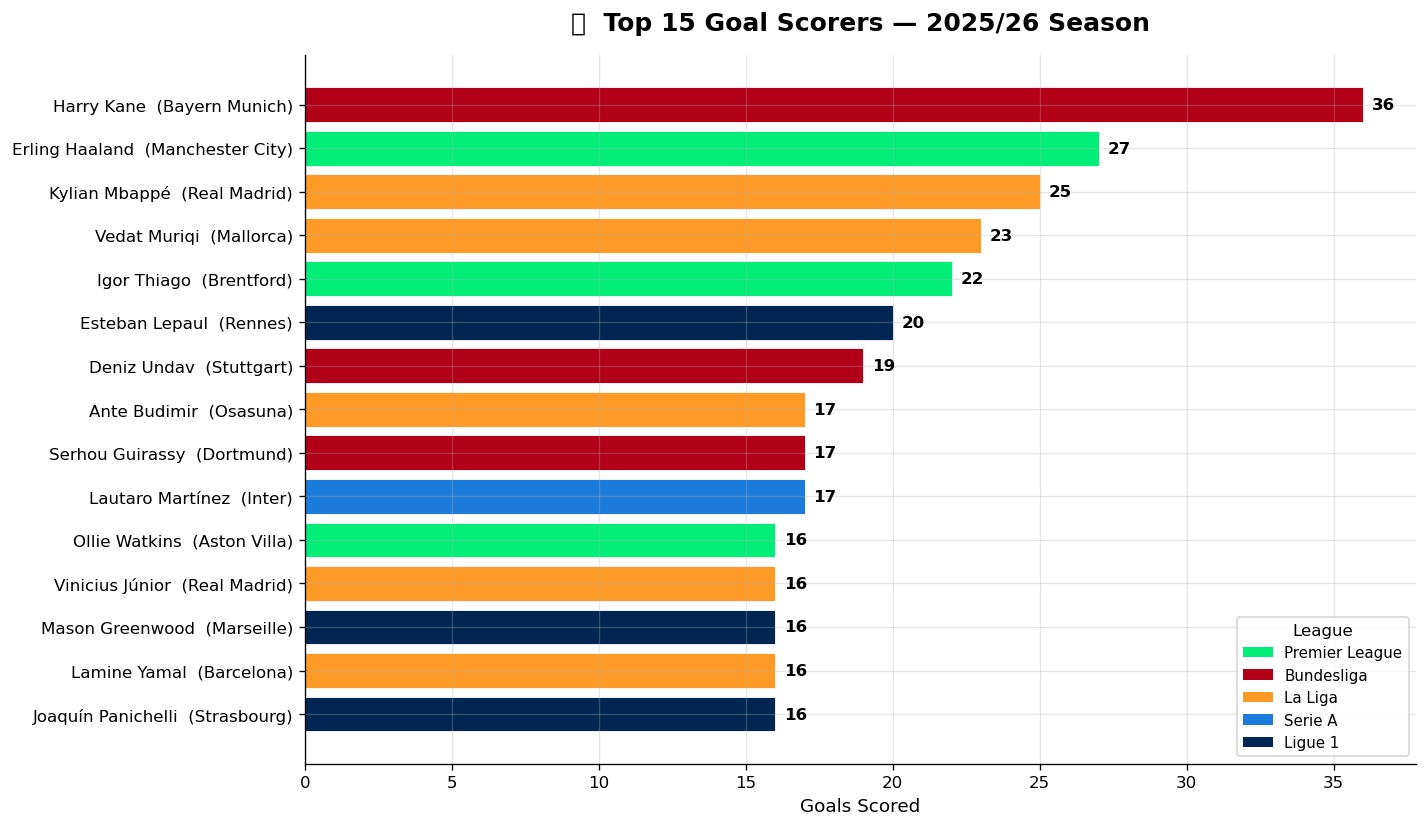

In [30]:
# ── Chart 1: Top 15 Goal Scorers ──
top_s = df[df['Position']!='GK'].nlargest(15,'Gls')
fig, ax = plt.subplots(figsize=(12,7))
colors = [LEAGUE_COLORS.get(l,'#888') for l in top_s['League']]
bars   = ax.barh(top_s['Player']+'  ('+top_s['Squad']+')', top_s['Gls'],
                 color=colors, edgecolor='white', linewidth=0.5)
for bar,v in zip(bars, top_s['Gls']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{int(v)}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Goals Scored'); ax.invert_yaxis()
ax.set_title('⚽  Top 15 Goal Scorers — 2025/26 Season', fontsize=15, fontweight='bold', pad=15)
legend_el = [Patch(facecolor=v, label=k) for k,v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_el, loc='lower right', fontsize=9, title='League')
plt.tight_layout(); save_fig('01_top_scorers.png'); plt.show()

   💾 Saved → visuals/02_top_assists.png


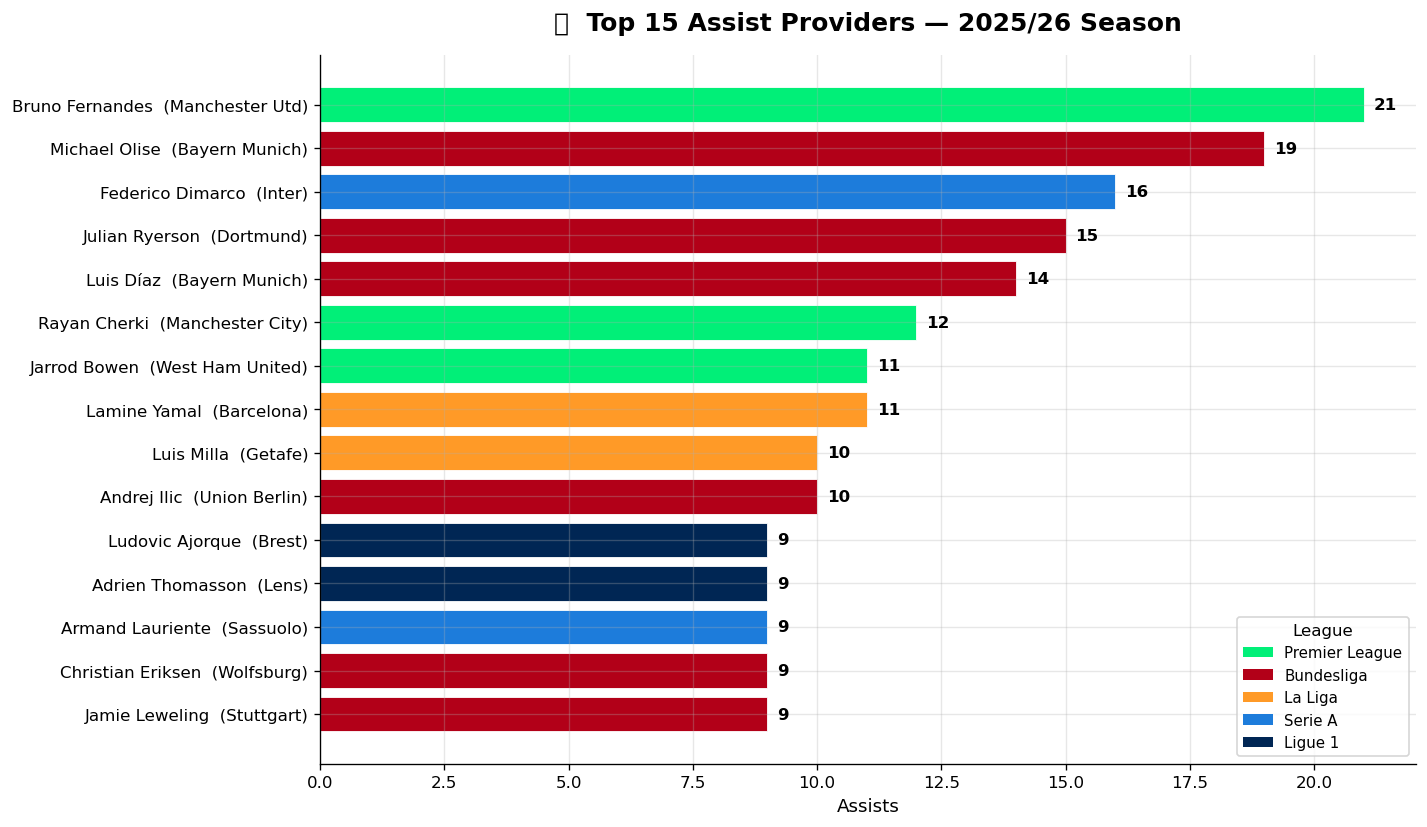

In [31]:
# ── Chart 2: Top 15 Assist Providers ──
top_a = df.nlargest(15,'Ast')
fig, ax = plt.subplots(figsize=(12,7))
colors = [LEAGUE_COLORS.get(l,'#888') for l in top_a['League']]
bars   = ax.barh(top_a['Player']+'  ('+top_a['Squad']+')', top_a['Ast'],
                 color=colors, edgecolor='white', linewidth=0.5)
for bar,v in zip(bars, top_a['Ast']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{int(v)}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Assists'); ax.invert_yaxis()
ax.set_title('🎯  Top 15 Assist Providers — 2025/26 Season', fontsize=15, fontweight='bold', pad=15)
legend_el = [Patch(facecolor=v, label=k) for k,v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_el, loc='lower right', fontsize=9, title='League')
plt.tight_layout(); save_fig('02_top_assists.png'); plt.show()

   💾 Saved → visuals/03_goals_by_league.png


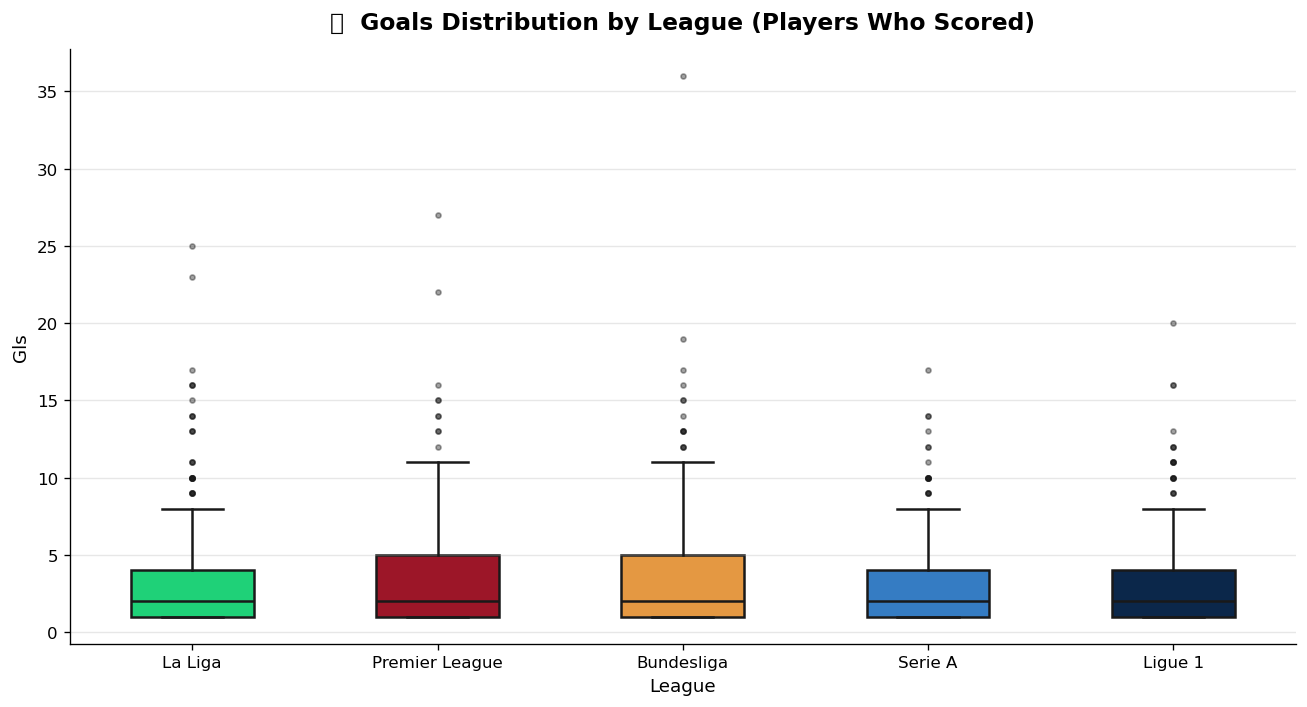

In [32]:
# ── Chart 3: Goals Distribution by League (Boxplot) ──
outfield_df = df[df['Position']!='GK']
scorers     = outfield_df[outfield_df['Gls']>0]
lg_order    = scorers.groupby('League')['Gls'].sum().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11,6))
sns.boxplot(data=scorers, x='League', y='Gls', order=lg_order,
            palette=list(LEAGUE_COLORS.values()), width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.set_title('⚽  Goals Distribution by League (Players Who Scored)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); save_fig('03_goals_by_league.png'); plt.show()

   💾 Saved → visuals/04_position_donut.png


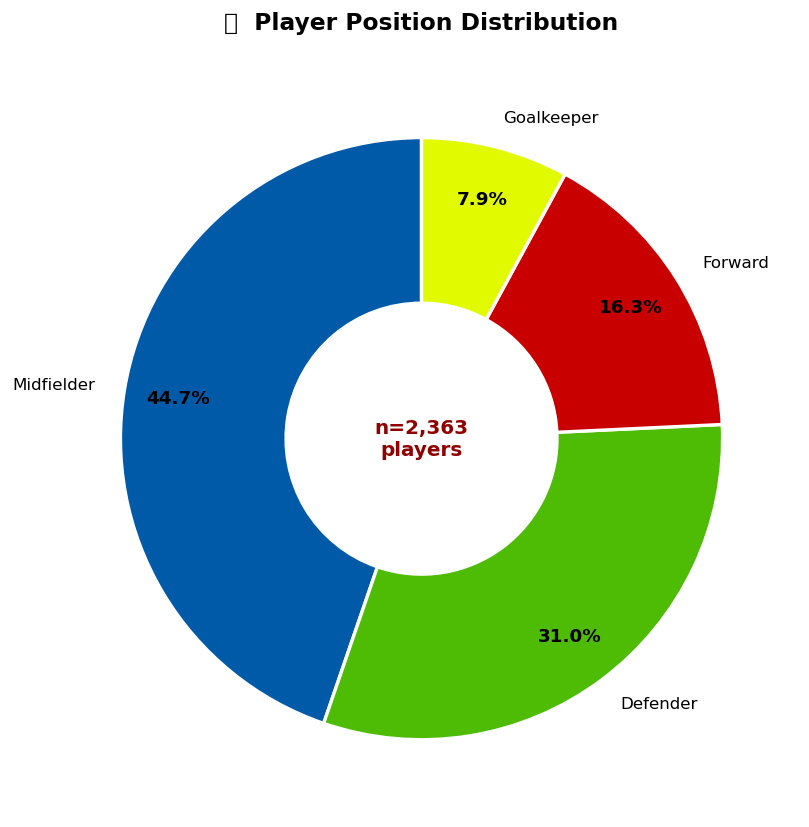

In [33]:
# ── Chart 4: Position Distribution (Donut) ──
pos_c = df['Position'].value_counts()
labels = {'GK':'Goalkeeper','DF':'Defender','MF':'Midfielder','FW':'Forward'}
clrs   = [POS_COLORS.get(p,'#ccc') for p in pos_c.index]
fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
    pos_c.values, labels=[labels.get(p,p) for p in pos_c.index],
    colors=clrs, autopct='%1.1f%%', startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
ax.text(0,0,f'n={len(df):,}\nplayers',ha='center',va='center',
        fontsize=12,fontweight='bold',color='#900000')
ax.set_title('🧍  Player Position Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); save_fig('04_position_donut.png'); plt.show()

   💾 Saved → visuals/05_age_distribution.png


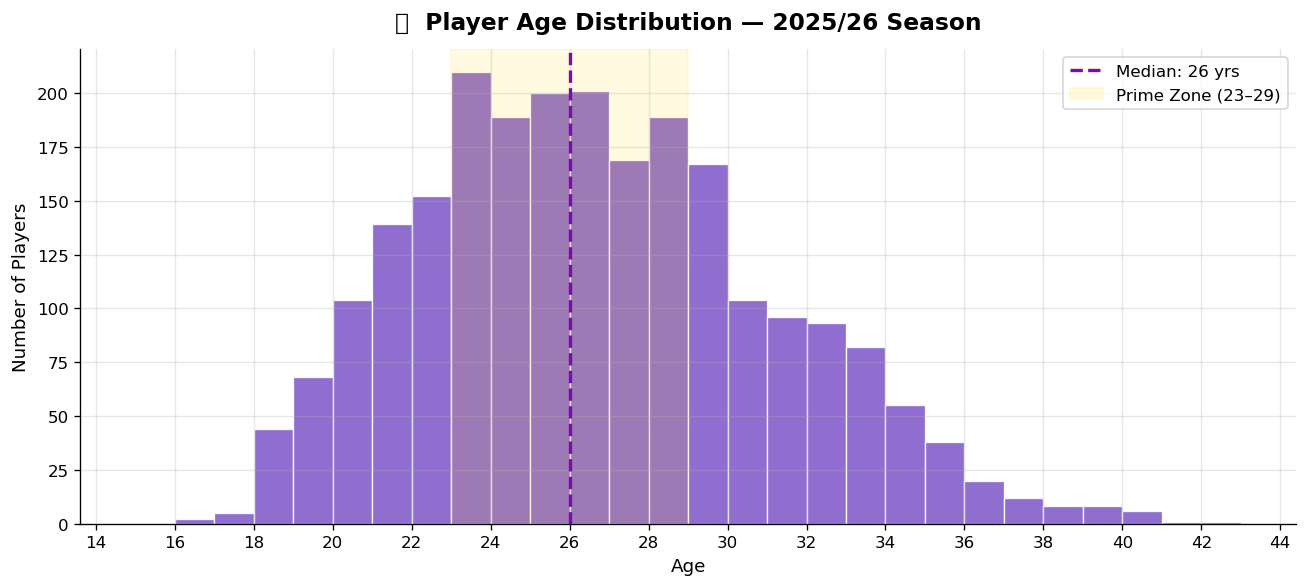

In [34]:
# ── Chart 5: Age Distribution ──
fig, ax = plt.subplots(figsize=(11,5))
ax.hist(df['Age'].dropna(), bins=range(15,44), color='#845eca',
        edgecolor='white', linewidth=0.8, alpha=0.9)
ax.axvline(df['Age'].median(), color='#7C0BAD', linewidth=2, linestyle='--',
           label=f'Median: {df["Age"].median():.0f} yrs')
ax.axvspan(23, 29, alpha=0.12, color='gold', label='Prime Zone (23–29)')
ax.set_xlabel('Age'); ax.set_ylabel('Number of Players')
ax.set_title('📅  Player Age Distribution — 2025/26 Season', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2)); ax.legend(fontsize=10)
plt.tight_layout(); save_fig('05_age_distribution.png'); plt.show()

   💾 Saved → visuals/06_goals_vs_assists.png


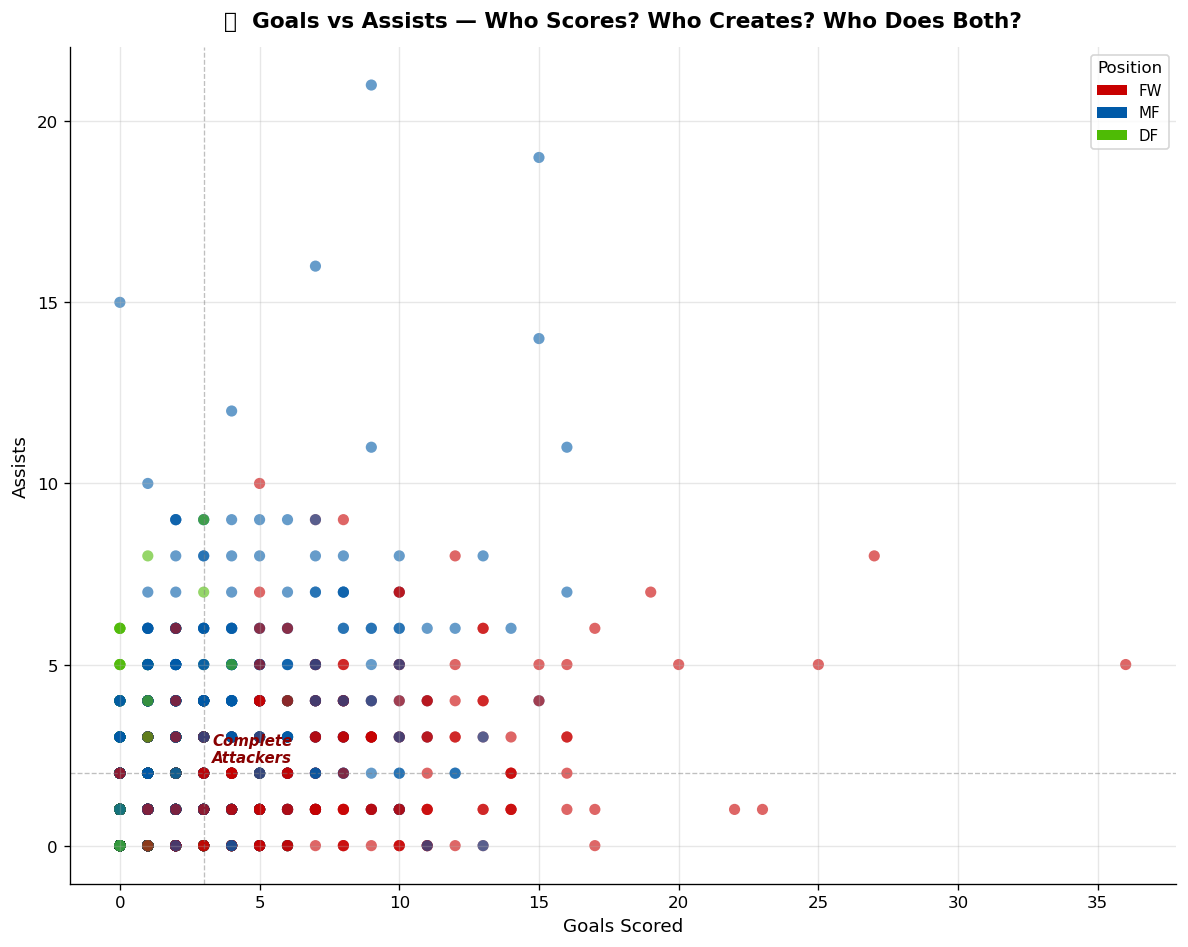

In [35]:
# ── Chart 6: Goals vs Assists Scatter ──
outfield = df[df['Position']!='GK'].copy()
sc_colors = [POS_COLORS.get(p,'#ccc') for p in outfield['Position']]
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(outfield['Gls'], outfield['Ast'], c=sc_colors, alpha=0.6, s=45, edgecolors='none')
ax.axvline(outfield['Gls'].quantile(0.75), color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(outfield['Ast'].quantile(0.75), color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(outfield['Gls'].quantile(0.75)+0.3, outfield['Ast'].quantile(0.75)+0.3,
        'Complete\nAttackers', fontsize=9, color='#880000', style='italic', fontweight='bold')
ax.set_xlabel('Goals Scored'); ax.set_ylabel('Assists')
ax.set_title('🎯  Goals vs Assists — Who Scores? Who Creates? Who Does Both?',
             fontsize=13, fontweight='bold', pad=12)
legend_el = [Patch(facecolor=v, label=k) for k,v in POS_COLORS.items() if k!='GK']
ax.legend(handles=legend_el, title='Position', fontsize=9)
plt.tight_layout(); save_fig('06_goals_vs_assists.png'); plt.show()

   💾 Saved → visuals/07_correlation_heatmap.png


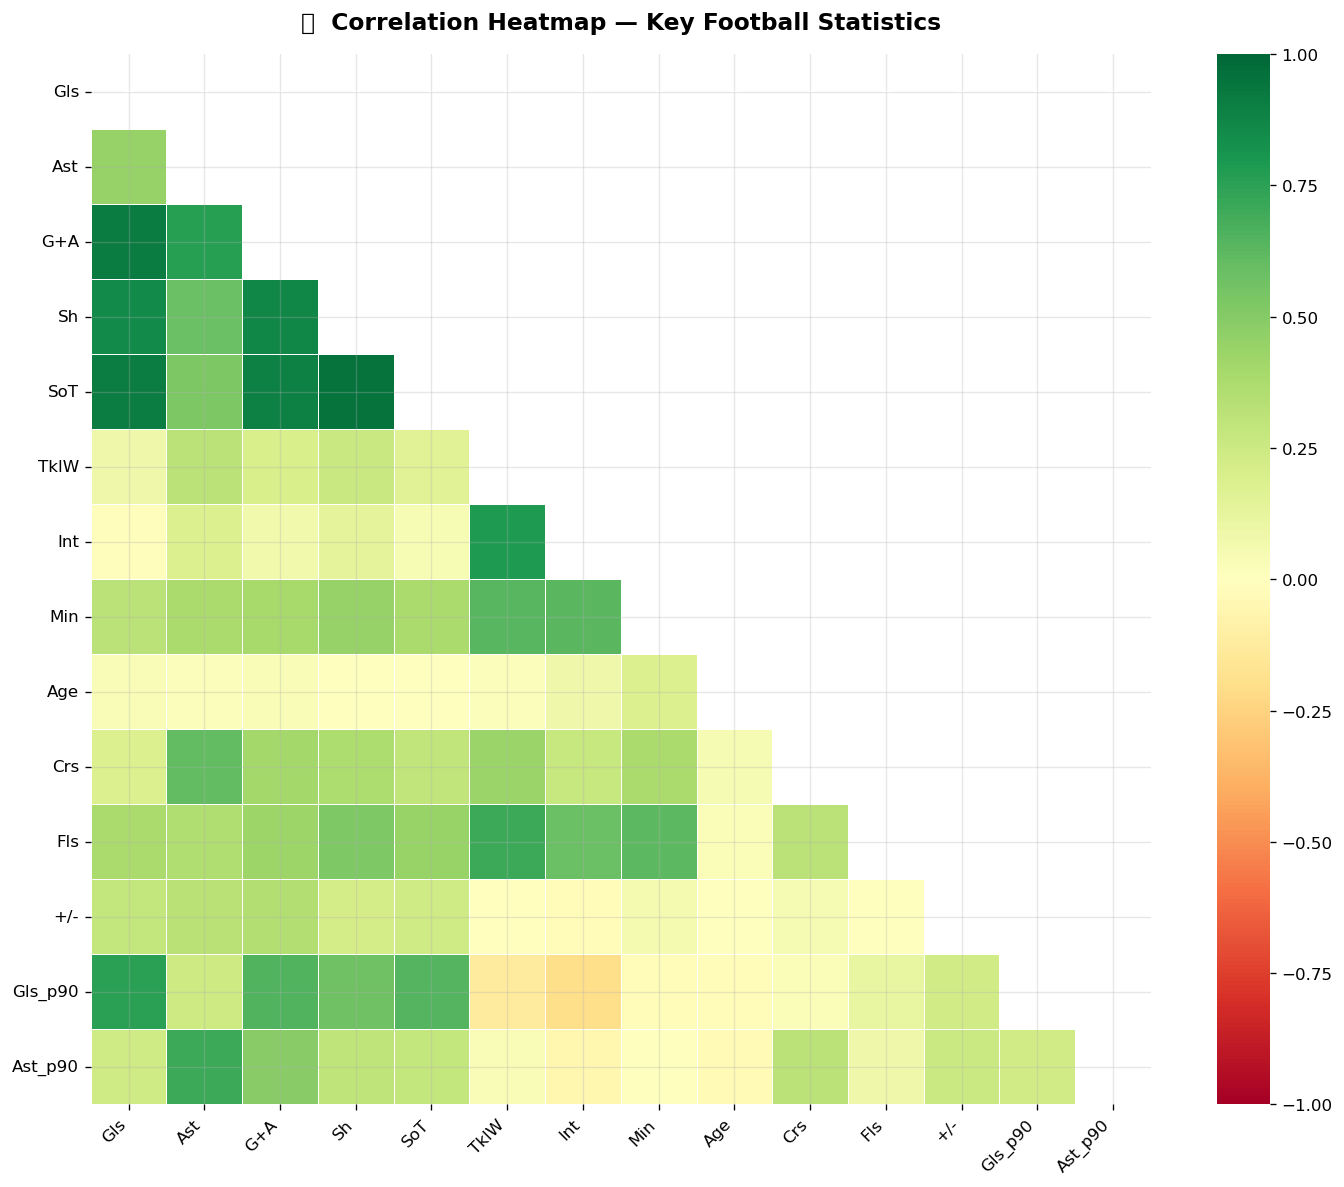

In [36]:
# ── Chart 7: Correlation Heatmap ──
corr_cols = ['Gls','Ast','G+A','Sh','SoT','TklW','Int','Min','Age','Crs','Fls','+/-','Gls_p90','Ast_p90']
corr_m    = df[corr_cols].corr()
mask      = np.triu(np.ones_like(corr_m, dtype=bool))
fig, ax   = plt.subplots(figsize=(12,10))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', linewidths=0.5,
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot_kws={'size':8}, ax=ax)
ax.set_title('🔗  Correlation Heatmap — Key Football Statistics', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); save_fig('07_correlation_heatmap.png'); plt.show()

   💾 Saved → visuals/08_stats_by_position.png


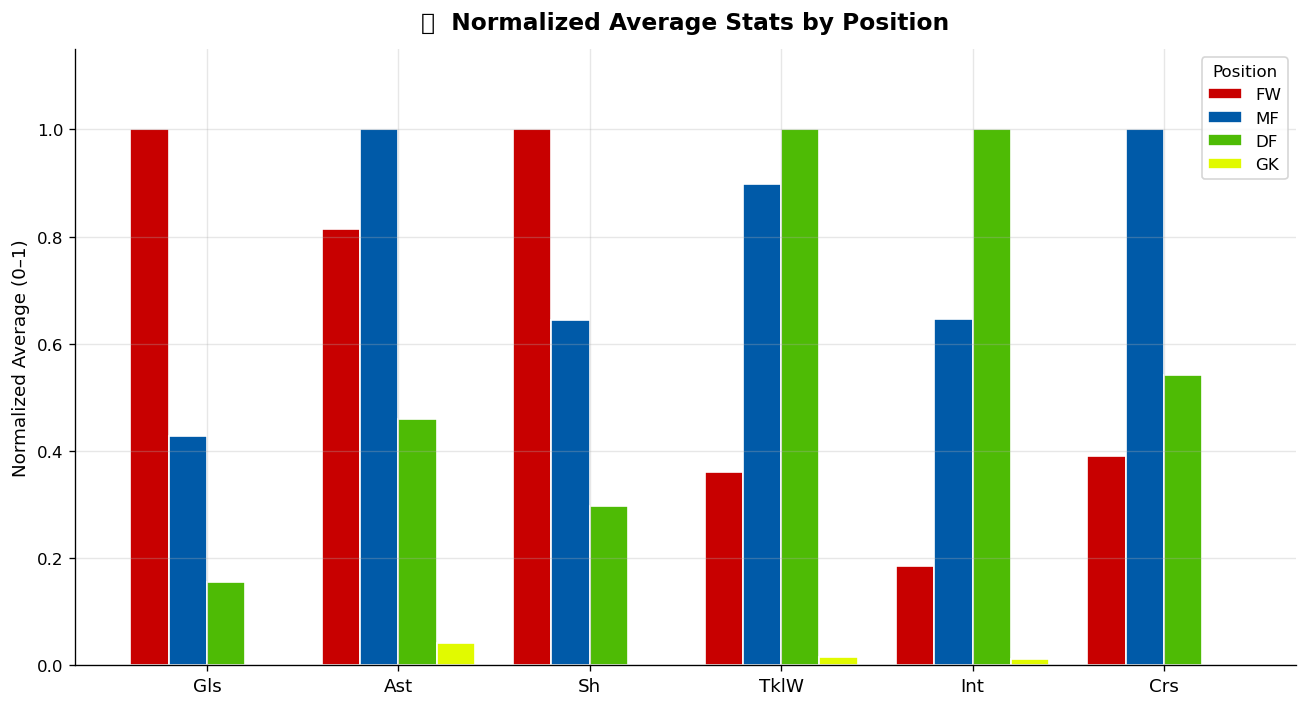

In [37]:
# ── Chart 8: Normalized Stats by Position ──
stat_cols = ['Gls','Ast','Sh','TklW','Int','Crs']
pos_avg   = df.groupby('Position')[stat_cols].mean().round(2)
pos_norm  = pos_avg.div(pos_avg.max())
pos_order = ['FW','MF','DF','GK']
x = np.arange(len(stat_cols)); width = 0.2
fig, ax = plt.subplots(figsize=(11,6))
for i, pos in enumerate(pos_order):
    if pos in pos_norm.index:
        vals = [pos_norm.loc[pos,c] if c in pos_norm.columns else 0 for c in stat_cols]
        ax.bar(x+i*width, vals, width, label=pos,
               color=POS_COLORS.get(pos,'#888'), edgecolor='white')
ax.set_xticks(x+width*1.5); ax.set_xticklabels(stat_cols, fontsize=11)
ax.set_ylabel('Normalized Average (0–1)'); ax.set_ylim(0,1.15)
ax.set_title('📊  Normalized Average Stats by Position', fontsize=14, fontweight='bold', pad=12)
ax.legend(title='Position', fontsize=10)
plt.tight_layout(); save_fig('08_stats_by_position.png'); plt.show()

   💾 Saved → visuals/09_top_defenders.png


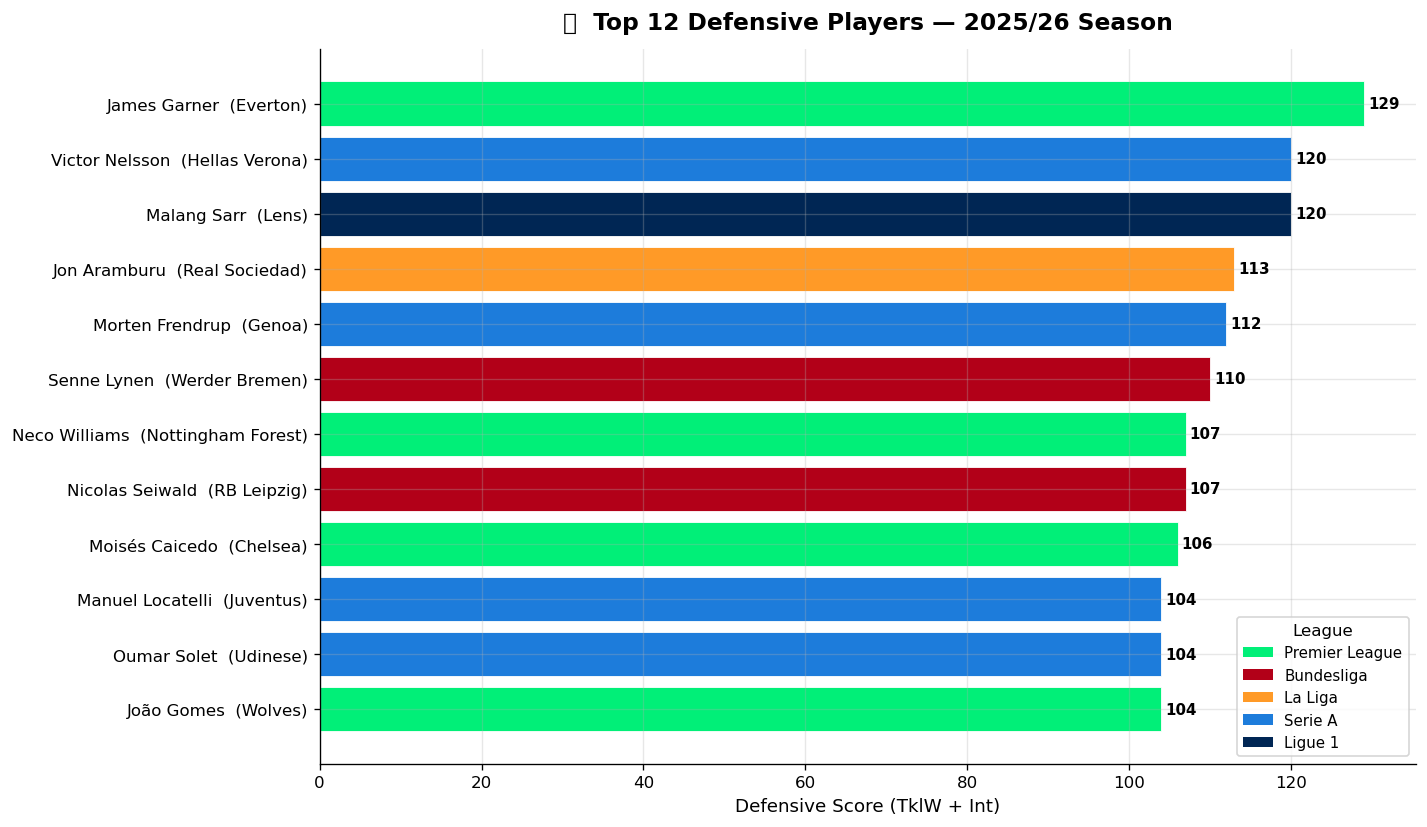

In [38]:
# ── Chart 9: Top 12 Defensive Players ──
def_df2 = df[df['Position'].isin(['DF','MF'])].copy()
def_df2['Def_Score'] = def_df2['TklW'] + def_df2['Int']
top_def = def_df2.nlargest(12,'Def_Score').reset_index(drop=True)
colors  = [LEAGUE_COLORS.get(l,'#888') for l in top_def['League']]
fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(top_def['Player']+'  ('+top_def['Squad']+')',
               top_def['Def_Score'], color=colors, edgecolor='white', linewidth=0.5)
for bar,v in zip(bars, top_def['Def_Score']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{int(v)}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Defensive Score (TklW + Int)')
ax.set_title('🛡️  Top 12 Defensive Players — 2025/26 Season', fontsize=14, fontweight='bold', pad=12)
legend_el = [Patch(facecolor=v, label=k) for k,v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_el, fontsize=9, title='League')
plt.tight_layout(); save_fig('09_top_defenders.png'); plt.show()

   💾 Saved → visuals/10_top_goalkeepers.png


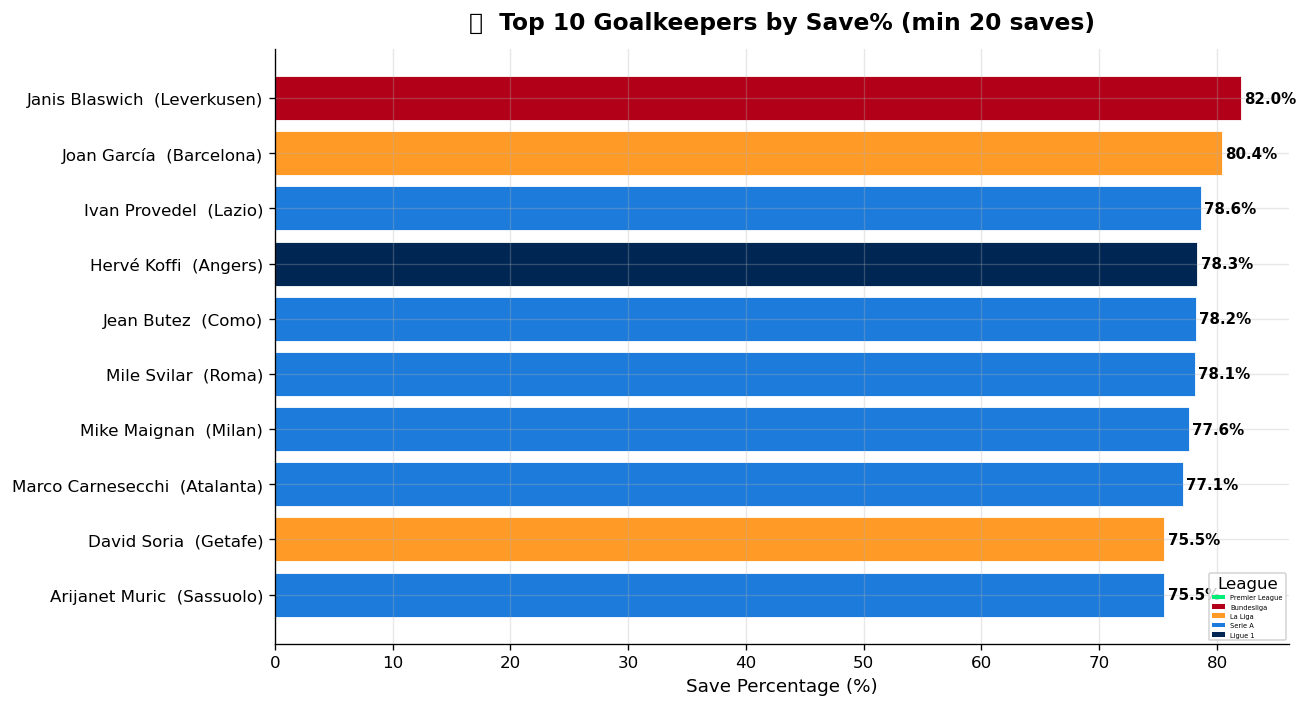

In [41]:
# ── Chart 10: Top 10 Goalkeepers by Save% ──
gk_active = df[(df['Position']=='GK')&(df['Saves']>=20)]
top_gk    = gk_active.nlargest(10,'Save%')
fig, ax   = plt.subplots(figsize=(11,6))
colors    = [LEAGUE_COLORS.get(l,'#888') for l in top_gk['League']]
bars = ax.barh(top_gk['Player']+'  ('+top_gk['Squad']+')',
               top_gk['Save%'], color=colors, edgecolor='white', linewidth=0.5)
for bar,v in zip(bars, top_gk['Save%']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Save Percentage (%)')
ax.set_title('🧤  Top 10 Goalkeepers by Save% (min 20 saves)', fontsize=14, fontweight='bold', pad=12)
legend_el = [Patch(facecolor=v, label=k) for k,v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_el, fontsize=4, title='League')
plt.tight_layout(); save_fig('10_top_goalkeepers.png'); plt.show()

## 📊 Advanced Visualizations — Charts 11–20
The following charts reveal insights **invisible in standard summaries** — efficiency quadrants, aging curves, league DNA fingerprints, underplayed gems, and more.

   💾 Saved → visuals/11_shooting_efficiency_quadrant.png


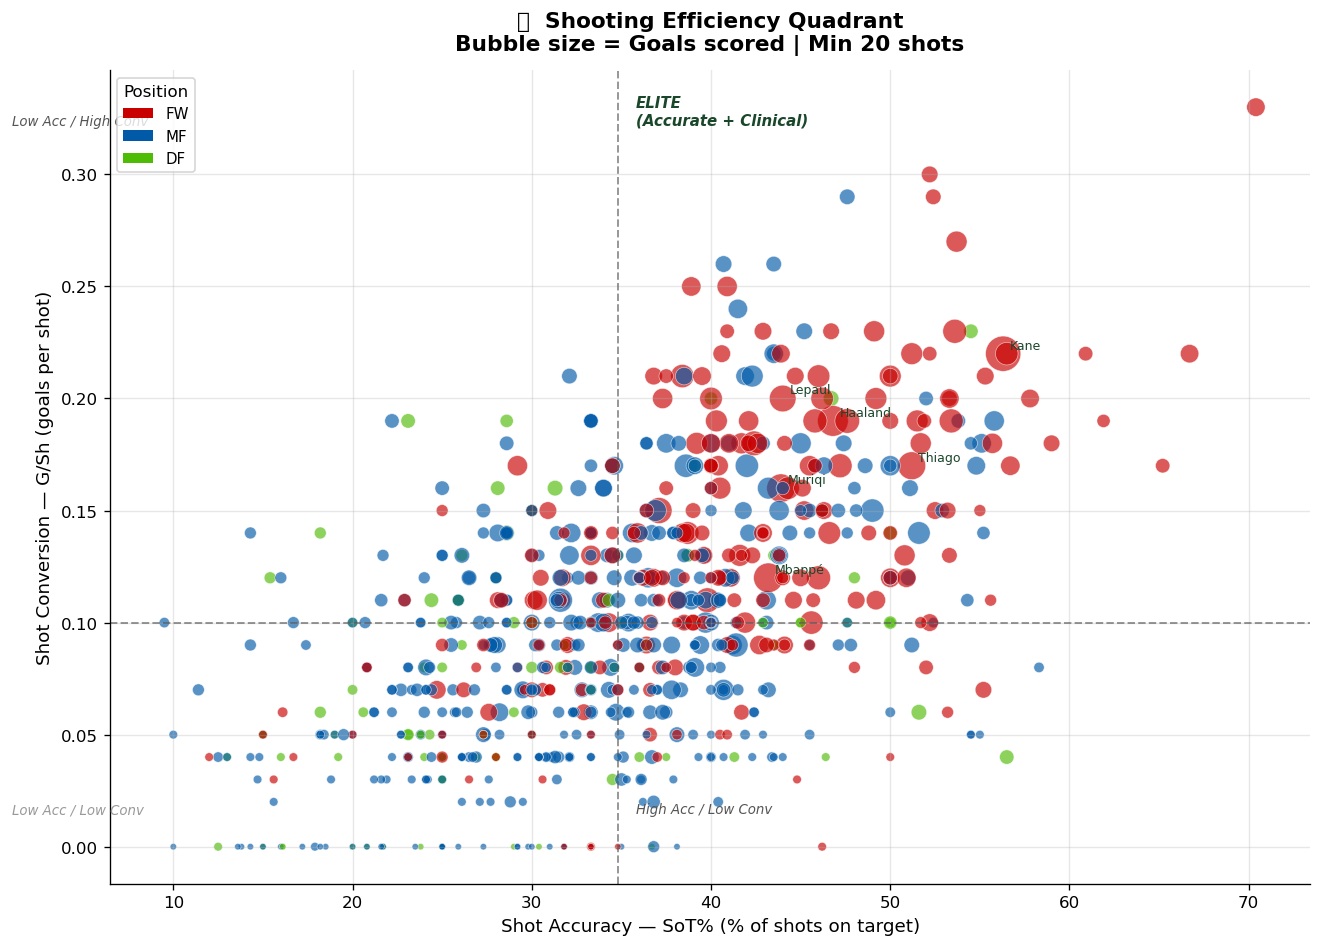

   Insight: Very few players achieve both high SoT% AND high G/Sh simultaneously.


In [42]:
# ── Chart 11: Shooting Efficiency Quadrant ──
# SoT% vs G/Sh — who is accurate AND clinical? Bubble size = goals.
shooters2 = df[(df['Sh']>=20)&(df['Position']!='GK')].copy()
sot_med2  = shooters2['SoT%'].median()
gsh_med2  = shooters2['G/Sh'].median()

fig, ax = plt.subplots(figsize=(11,8))
sc_c = [POS_COLORS.get(p,'#ccc') for p in shooters2['Position']]
ax.scatter(shooters2['SoT%'], shooters2['G/Sh'],
           c=sc_c, s=shooters2['Gls']*12+15,
           alpha=0.65, edgecolors='white', linewidth=0.4)
ax.axvline(sot_med2, color='#555', linewidth=1.2, linestyle='--', alpha=0.6)
ax.axhline(gsh_med2, color='#555', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(sot_med2+1, ax.get_ylim()[1]*0.93, 'ELITE\n(Accurate + Clinical)',
        fontsize=9, color='#1a472a', fontweight='bold', style='italic')
ax.text(1, ax.get_ylim()[1]*0.93, 'Low Acc / High Conv',
        fontsize=8, color='#555', style='italic')
ax.text(sot_med2+1, gsh_med2*0.15, 'High Acc / Low Conv',
        fontsize=8, color='#555', style='italic')
ax.text(1, gsh_med2*0.15, 'Low Acc / Low Conv',
        fontsize=8, color='#999', style='italic')
elite2 = shooters2[(shooters2['SoT%']>=sot_med2)&(shooters2['G/Sh']>=gsh_med2)].nlargest(6,'Gls')
for _, row in elite2.iterrows():
    ax.annotate(row['Player'].split()[-1], (row['SoT%'], row['G/Sh']),
                textcoords='offset points', xytext=(4,3), fontsize=7.5, color='#1a472a')
ax.set_xlabel('Shot Accuracy — SoT% (% of shots on target)')
ax.set_ylabel('Shot Conversion — G/Sh (goals per shot)')
ax.set_title('🎯  Shooting Efficiency Quadrant\nBubble size = Goals scored | Min 20 shots',
             fontsize=13, fontweight='bold', pad=12)
legend_el = [Patch(facecolor=v, label=k) for k,v in POS_COLORS.items() if k!='GK']
ax.legend(handles=legend_el, title='Position', fontsize=9)
plt.tight_layout(); save_fig('11_shooting_efficiency_quadrant.png'); plt.show()
print('   Insight: Very few players achieve both high SoT% AND high G/Sh simultaneously.')

   💾 Saved → visuals/12_aging_curve.png


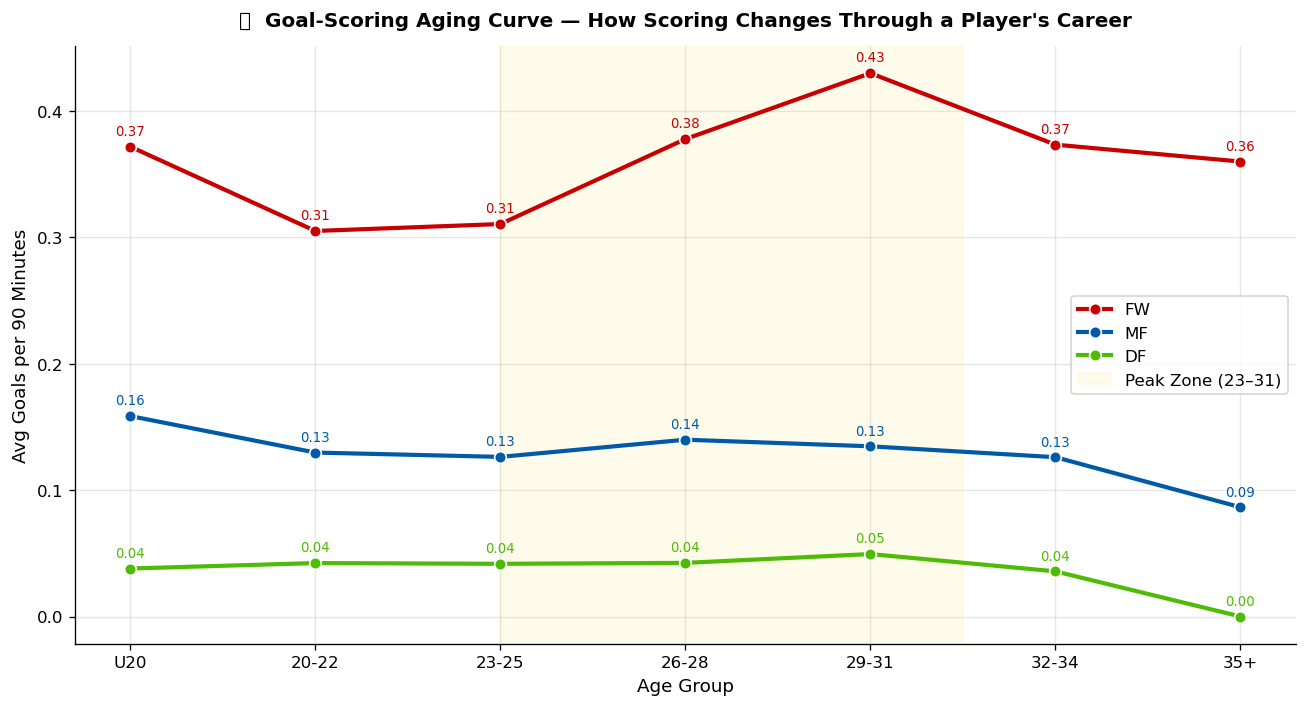

   Insight: FW peaks at 26-31. DF scoring (set-pieces) peaks later at 29-34.


In [43]:
# ── Chart 12: Goal-Scoring Aging Curve by Position ──
outfield2  = df[(df['Position']!='GK')&(df['Min']>=500)].copy()
age_curve  = outfield2.groupby(['AgeGroup','Position'], observed=True)['Gls_p90'].mean().reset_index()
age_labels = ['U20','20-22','23-25','26-28','29-31','32-34','35+']
x = np.arange(len(age_labels))

fig, ax = plt.subplots(figsize=(11,6))
for pos, color in [('FW','#c80000'),('MF','#005aa8'),('DF','#4ebb05')]:
    sub  = age_curve[age_curve['Position']==pos].set_index('AgeGroup')
    vals = [float(sub.loc[ag,'Gls_p90']) if ag in sub.index else np.nan for ag in age_labels]
    ax.plot(x, vals, 'o-', color=color, linewidth=2.5, markersize=7,
            label=pos, markeredgecolor='white', markeredgewidth=1)
    for xi,v in zip(x,vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.2f}', (xi,v), textcoords='offset points',
                        xytext=(0,7), ha='center', fontsize=8, color=color)
ax.axvspan(2, 4.5, alpha=0.08, color='gold', label='Peak Zone (23–31)')
ax.set_xticks(x); ax.set_xticklabels(age_labels, fontsize=10)
ax.set_xlabel('Age Group'); ax.set_ylabel('Avg Goals per 90 Minutes')
ax.set_title("📈  Goal-Scoring Aging Curve — How Scoring Changes Through a Player's Career",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout(); save_fig('12_aging_curve.png'); plt.show()
print('   Insight: FW peaks at 26-31. DF scoring (set-pieces) peaks later at 29-34.')

   💾 Saved → visuals/13_league_dna_radar.png


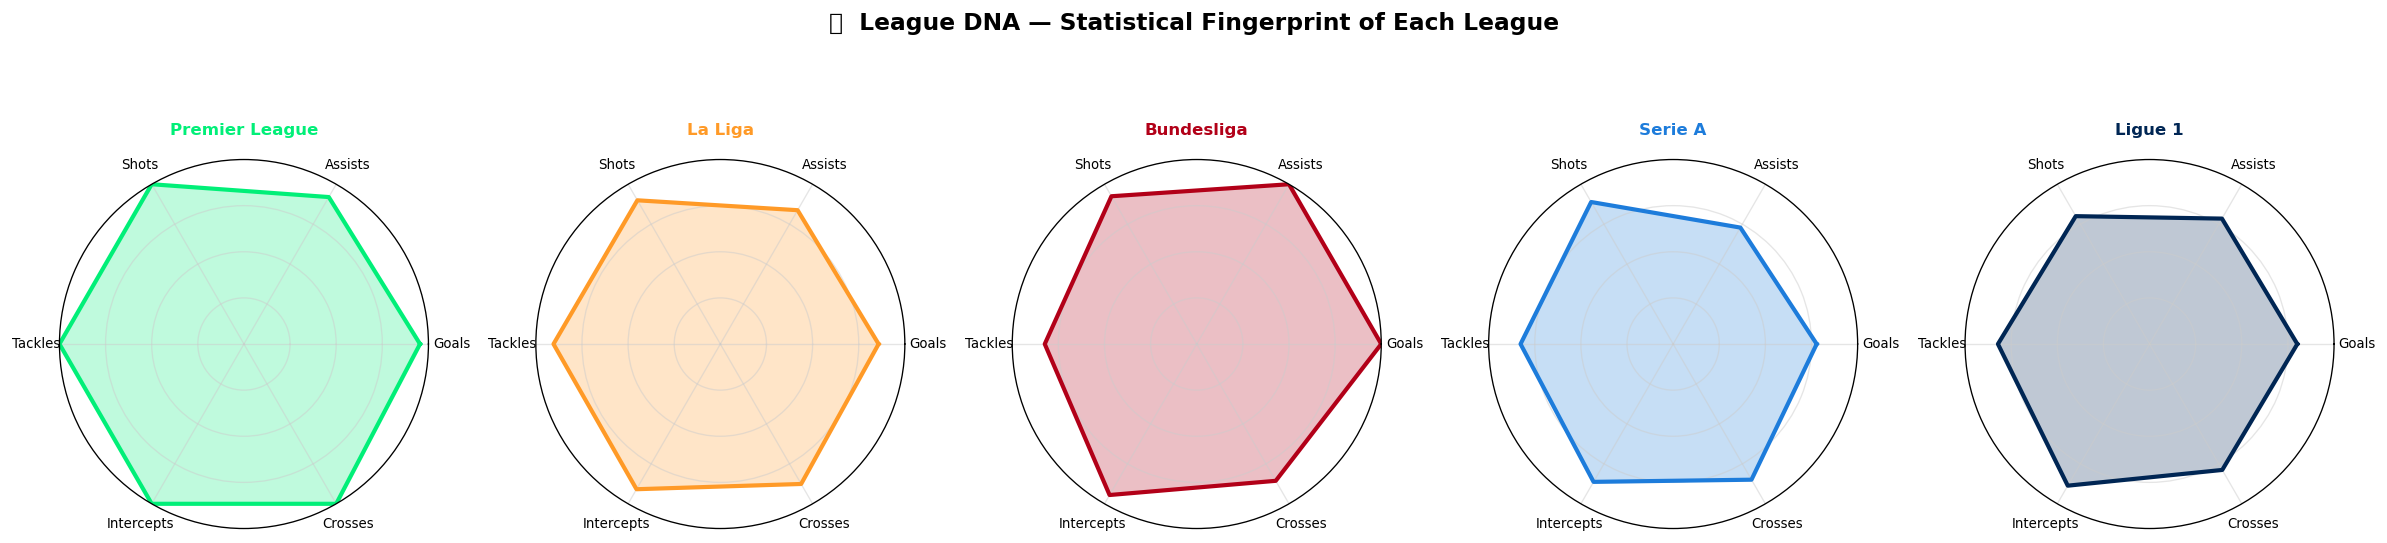

   Insight: Bundesliga widest attacking footprint. Serie A leans defensive, Premier League is balanced(Complete).


In [45]:
# ── Chart 13: League DNA Radar ──
metrics   = ['Gls','Ast','Sh','TklW','Int','Crs']
m_labels  = ['Goals','Assists','Shots','Tackles','Intercepts','Crosses']
N = len(metrics)
lg_avg    = df.groupby('League')[metrics].mean()
lg_norm   = lg_avg.div(lg_avg.max())
lg_order  = ['Premier League','La Liga','Bundesliga','Serie A','Ligue 1']

fig, axes = plt.subplots(1, 5, figsize=(20,5), subplot_kw=dict(polar=True))
fig.suptitle('🧬  League DNA — Statistical Fingerprint of Each League',
             fontsize=14, fontweight='bold', y=1.02)
for ax_r, league in zip(axes, lg_order):
    color = LEAGUE_COLORS[league]
    vals  = [lg_norm.loc[league,m] for m in metrics] + [lg_norm.loc[league,metrics[0]]]
    angles= [n/N*2*np.pi for n in range(N)] + [0]
    ax_r.plot(angles, vals, color=color, linewidth=2.5)
    ax_r.fill(angles, vals, color=color, alpha=0.25)
    ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(m_labels, size=8)
    ax_r.set_ylim(0,1); ax_r.set_yticks([0.25,0.5,0.75])
    ax_r.set_yticklabels(['','','']); ax_r.set_title(league, size=10, fontweight='bold', pad=15, color=color)
    ax_r.grid(color='#ccc', alpha=0.5)
plt.tight_layout(); save_fig('13_league_dna_radar.png'); plt.show()
print('   Insight: Bundesliga widest attacking footprint. Serie A leans defensive, Premier League is balanced(Complete).')

   💾 Saved → visuals/14_player_value_map.png


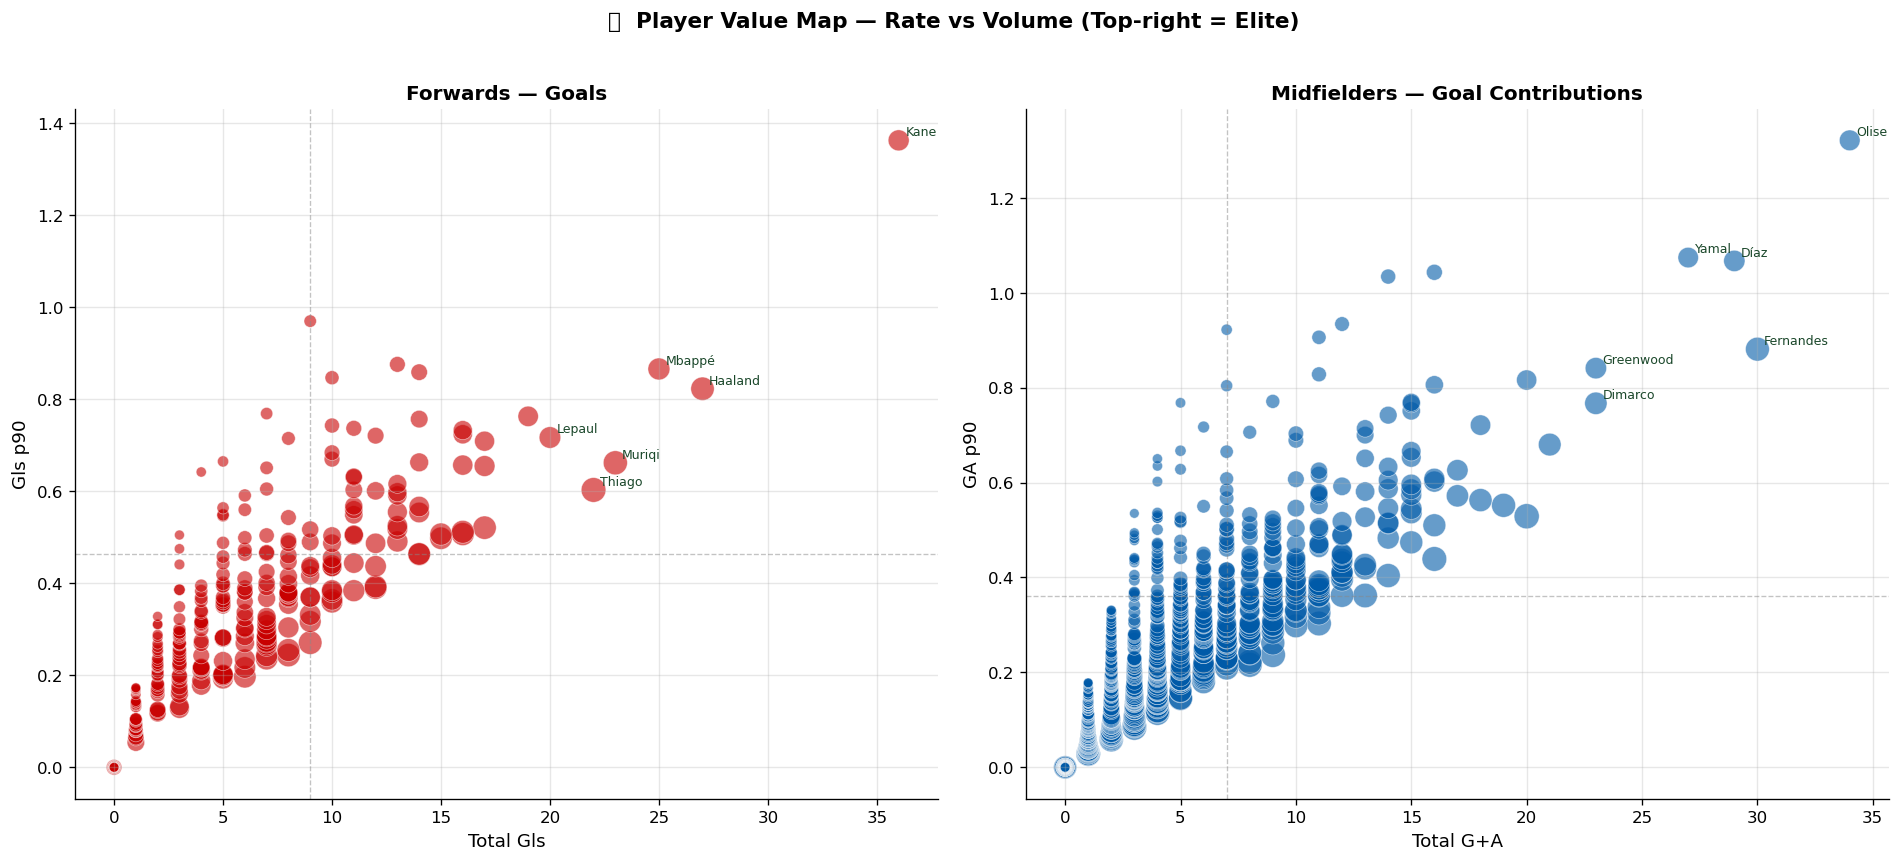

   Insight: Bubble size = minutes played. Large bubble top-right = elite workhorse.


In [46]:
# ── Chart 14: Player Value Map — Rate vs Volume ──
fwds2 = df[(df['Position']=='FW')&(df['Min']>=500)].copy()
mids2 = df[(df['Position']=='MF')&(df['Min']>=500)].copy()
fig, axes = plt.subplots(1, 2, figsize=(16,7))
fig.suptitle('🗺️  Player Value Map — Rate vs Volume (Top-right = Elite)',
             fontsize=13, fontweight='bold', y=1.02)
for ax, sub, y_col, y_rate, label, color in [
    (axes[0], fwds2, 'Gls', 'Gls_p90', 'Forwards — Goals', '#c80000'),
    (axes[1], mids2, 'G+A', 'GA_p90',  'Midfielders — Goal Contributions', '#005aa8'),
]:
    ax.scatter(sub[y_col], sub[y_rate], s=sub['Min']/15,
               c=color, alpha=0.6, edgecolors='white', linewidth=0.4)
    ax.axvline(sub[y_col].quantile(0.75), color='#888', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(sub[y_rate].quantile(0.75), color='#888', linewidth=0.8, linestyle='--', alpha=0.5)
    for _, row in sub.nlargest(6,y_col).iterrows():
        ax.annotate(row['Player'].split()[-1], (row[y_col], row[y_rate]),
                    textcoords='offset points', xytext=(4,3), fontsize=7.5, color='#1a472a')
    ax.set_xlabel(f'Total {y_col}'); ax.set_ylabel(y_rate.replace('_',' '))
    ax.set_title(label, fontsize=12, fontweight='bold')
plt.tight_layout(); save_fig('14_player_value_map.png'); plt.show()
print('   Insight: Bubble size = minutes played. Large bubble top-right = elite workhorse.')

   💾 Saved → visuals/15_defensive_workrate_heatmap.png


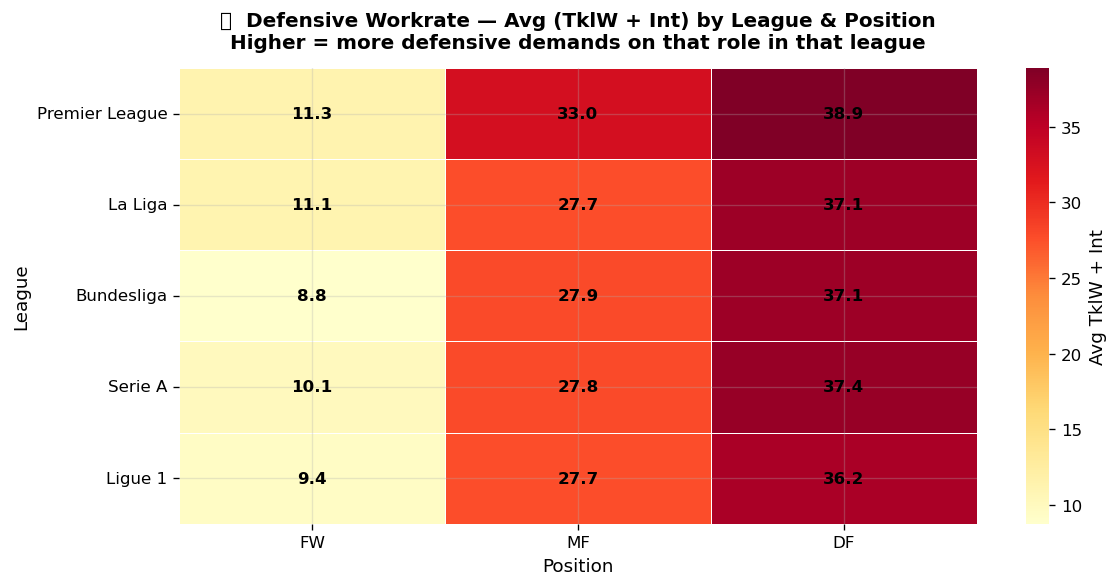

   Insight: Premier League demands most defensive work from all positions.


In [49]:
# ...existing code...
# ── Chart 15: Defensive Workrate Heatmap (League × Position) ──
def_pivot = df[df['Position'].isin(['FW','MF','DF'])].groupby(
    ['League','Position'])['DefScore'].mean().unstack(fill_value=0)

pos_order    = ['FW','MF','DF']
league_order = ['Premier League','La Liga','Bundesliga','Serie A','Ligue 1']
def_pivot = def_pivot.reindex(index=league_order, columns=pos_order)

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(def_pivot, annot=False, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Avg TklW + Int'}, ax=ax)

for i in range(def_pivot.shape[0]):
    for j in range(def_pivot.shape[1]):
        value = def_pivot.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f'{value:.1f}',
                ha='center', va='center', color='black',
                fontsize=10, fontweight='bold')

ax.set_title('🛡️  Defensive Workrate — Avg (TklW + Int) by League & Position\n'
             'Higher = more defensive demands on that role in that league',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout(); save_fig('15_defensive_workrate_heatmap.png'); plt.show()
print('   Insight: Premier League demands most defensive work from all positions.')
# ...existing code...

   💾 Saved → visuals/16_underplayed_gems.png


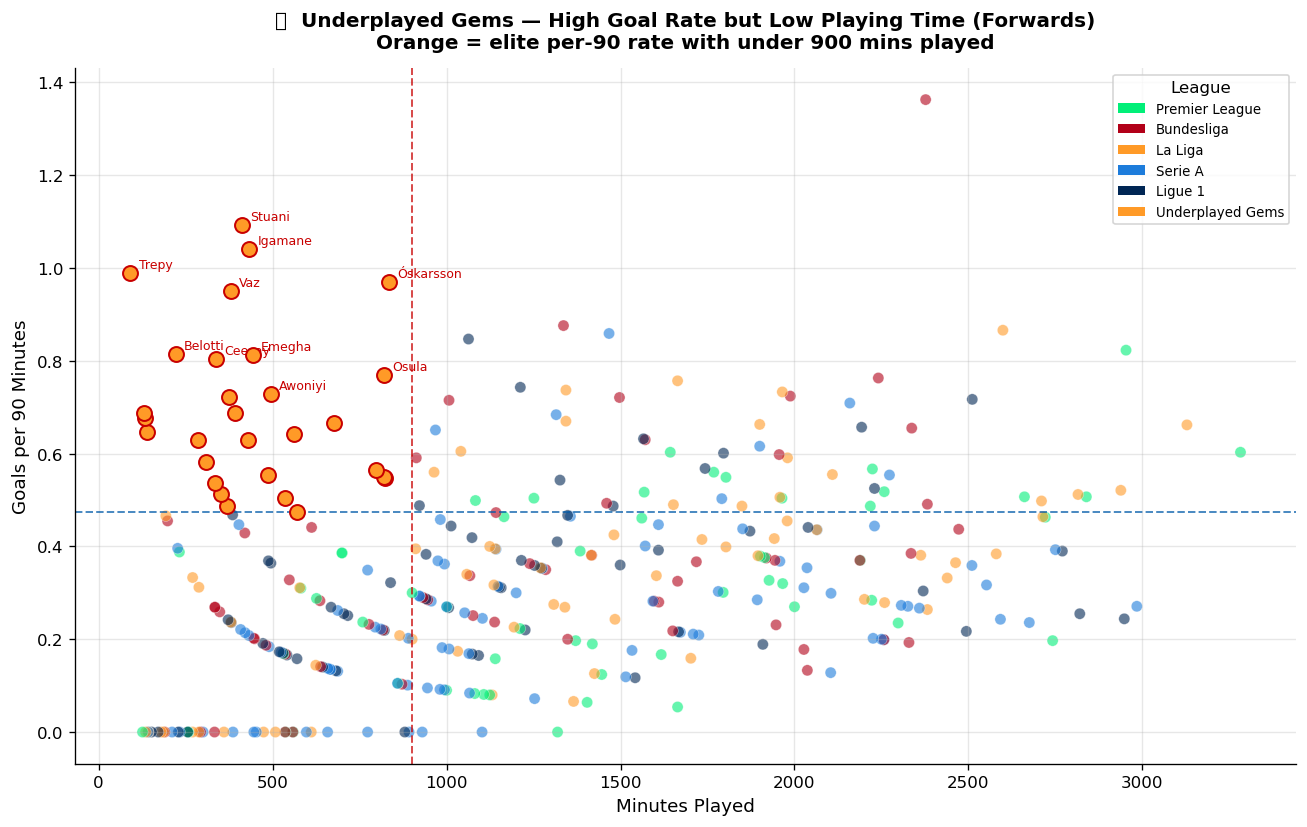

   Insight: Orange dots = forwards with elite per-90 rates but not getting minutes.


In [52]:
# ── Chart 16: Underplayed Gems — High Rate / Low Minutes ──
fwds3 = df[(df['Position']=='FW')&(df['Sh']>=5)].copy()
gems  = fwds3[(fwds3['Min']<900)&(fwds3['Gls_p90']>=fwds3['Gls_p90'].quantile(0.75))]
fig, ax = plt.subplots(figsize=(11,7))
sc_c = [LEAGUE_COLORS.get(l,'#888') for l in fwds3['League']]
ax.scatter(fwds3['Min'], fwds3['Gls_p90'], c=sc_c, alpha=0.6, s=45,
           edgecolors='white', linewidth=0.3)
ax.scatter(gems['Min'], gems['Gls_p90'], s=80, c='#ff9a27',
           edgecolors='#c80000', linewidth=1.2, zorder=5, label='Underplayed Gems')
ax.axvline(900, color='#c80000', linewidth=1.2, linestyle='--', alpha=0.7,
           label='900 min (10 matches)')
ax.axhline(fwds3['Gls_p90'].quantile(0.75), color='#005aa8', linewidth=1.2,
           linestyle='--', alpha=0.7, label='Top 25% rate')
for _, row in gems.nlargest(10,'Gls_p90').iterrows():
    ax.annotate(row['Player'].split()[-1], (row['Min'], row['Gls_p90']),
                textcoords='offset points', xytext=(5,3), fontsize=7.5, color='#c80000')
ax.set_xlabel('Minutes Played'); ax.set_ylabel('Goals per 90 Minutes')
ax.set_title('💎  Underplayed Gems — High Goal Rate but Low Playing Time (Forwards)\n'
             'Orange = elite per-90 rate with under 900 mins played',
             fontsize=12, fontweight='bold', pad=12)
legend_el = [Patch(facecolor=v, label=k) for k,v in LEAGUE_COLORS.items()]
ax.legend(handles=legend_el+[Patch(facecolor='#ff9a27',label='Underplayed Gems')],
          title='League', fontsize=8, loc='upper right')
plt.tight_layout(); save_fig('16_underplayed_gems.png'); plt.show()
print('   Insight: Orange dots = forwards with elite per-90 rates but not getting minutes.')

   💾 Saved → visuals/17_discipline_cards.png


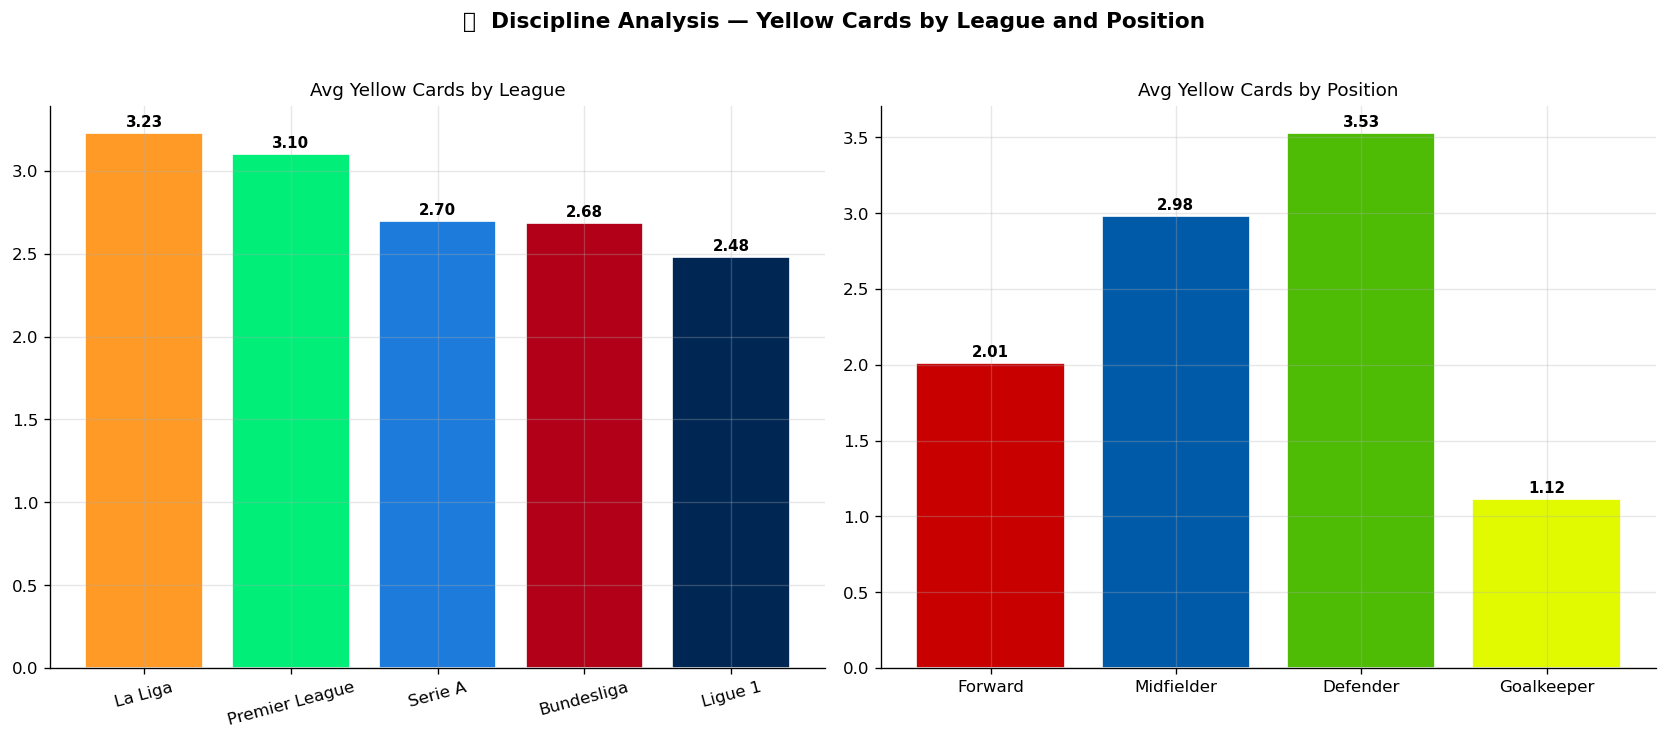

In [53]:
# ── Chart 17: Discipline — Cards by League & Position ──
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('🟨  Discipline Analysis — Yellow Cards by League and Position',
             fontsize=13, fontweight='bold', y=1.02)
lg_cards  = df.groupby('League')['CrdY'].mean().sort_values(ascending=False)
colors_lc = [LEAGUE_COLORS[l] for l in lg_cards.index]
bars = axes[0].bar(lg_cards.index, lg_cards.values, color=colors_lc, edgecolor='white')
for bar,v in zip(bars, lg_cards.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Avg Yellow Cards by League', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
pos_cards = df.groupby('Position')['CrdY'].mean().reindex(['FW','MF','DF','GK'])
colors_pc = [POS_COLORS[p] for p in pos_cards.index]
bars2 = axes[1].bar(['Forward','Midfielder','Defender','Goalkeeper'],
                    pos_cards.values, color=colors_pc, edgecolor='white')
for bar,v in zip(bars2, pos_cards.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Avg Yellow Cards by Position', fontsize=11)
plt.tight_layout(); save_fig('17_discipline_cards.png'); plt.show()

   💾 Saved → visuals/18_goals_vs_plusminus.png


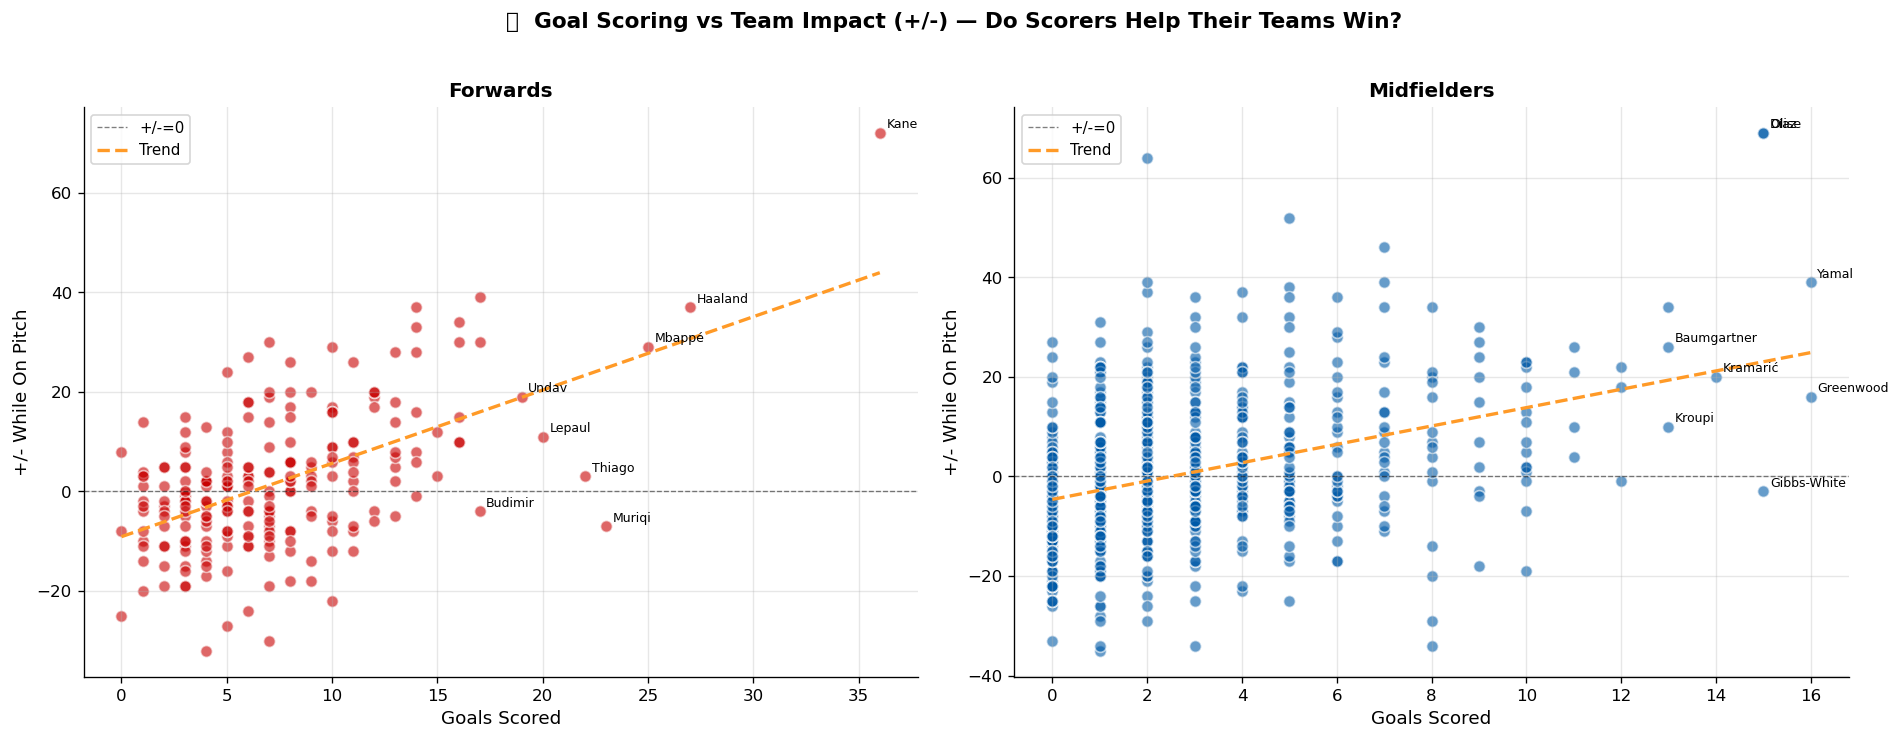

   Insight: Most top scorers have positive +/-, but some on weaker teams buck the trend.


In [55]:
# ── Chart 18: Goals vs +/- Team Impact ──
if '+/-' in df.columns:
    impact = df[(df['Min']>=900)&(df['Position'].isin(['FW','MF']))].copy()
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    fig.suptitle('📊  Goal Scoring vs Team Impact (+/-) — Do Scorers Help Their Teams Win?',
                 fontsize=13, fontweight='bold', y=1.02)
    for ax, pos, color, label in [
        (axes[0], 'FW', '#c80000', 'Forwards'),
        (axes[1], 'MF', '#005aa8', 'Midfielders')
    ]:
        sub = impact[impact['Position']==pos]
        ax.scatter(sub['Gls'], sub['+/-'], c=color, alpha=0.6, s=50, edgecolors='white')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, label='+/-=0')
        clean = sub[sub['Gls'].notna()&sub['+/-'].notna()]
        z  = np.polyfit(clean['Gls'], clean['+/-'], 1)
        xl = np.linspace(clean['Gls'].min(), clean['Gls'].max(), 100)
        ax.plot(xl, np.poly1d(z)(xl), '--', color='#ff9a27', linewidth=2, label='Trend')
        for _, row in sub.nlargest(8,'Gls').iterrows():
            ax.annotate(row['Player'].split()[-1], (row['Gls'], row['+/-']),
                        textcoords='offset points', xytext=(4,3), fontsize=7.5)
        ax.set_xlabel('Goals Scored'); ax.set_ylabel('+/- While On Pitch')
        ax.set_title(label, fontsize=12, fontweight='bold'); ax.legend(fontsize=9)
    plt.tight_layout(); save_fig('18_goals_vs_plusminus.png'); plt.show()
    print('   Insight: Most top scorers have positive +/-, but some on weaker teams buck the trend.')

   💾 Saved → visuals/19_goalkeeper_matrix.png


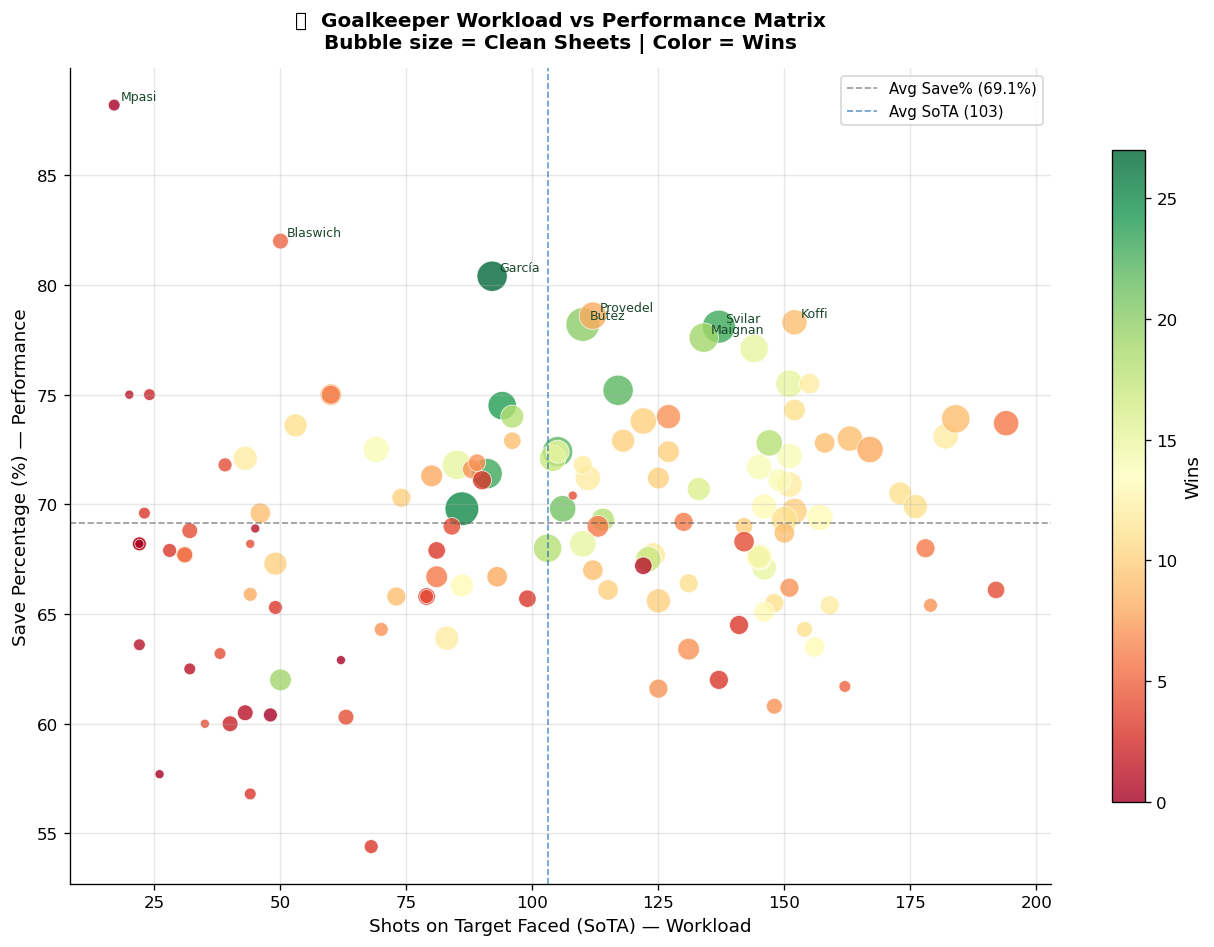

   Insight: Top-right with large bubble = elite GK on defensive team.


In [56]:
# ── Chart 19: Goalkeeper Workload vs Performance Matrix ──
gk_plot = df[(df['Position']=='GK')&(df['Saves']>=15)].copy()
fig, ax  = plt.subplots(figsize=(11,8))
sc = ax.scatter(gk_plot['SoTA'], gk_plot['Save%'],
                s=gk_plot['CS']*20+30, c=gk_plot['W'],
                cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Wins', shrink=0.8)
ax.axhline(gk_plot['Save%'].mean(), color='#555', linewidth=1, linestyle='--', alpha=0.6,
           label=f"Avg Save% ({gk_plot['Save%'].mean():.1f}%)")
ax.axvline(gk_plot['SoTA'].mean(), color='#005aa8', linewidth=1, linestyle='--', alpha=0.6,
           label=f"Avg SoTA ({gk_plot['SoTA'].mean():.0f})")
for _, row in gk_plot.nlargest(8,'Save%').iterrows():
    ax.annotate(row['Player'].split()[-1], (row['SoTA'], row['Save%']),
                textcoords='offset points', xytext=(4,3), fontsize=7.5, color='#1a472a')
ax.set_xlabel('Shots on Target Faced (SoTA) — Workload')
ax.set_ylabel('Save Percentage (%) — Performance')
ax.set_title('🧤  Goalkeeper Workload vs Performance Matrix\nBubble size = Clean Sheets | Color = Wins',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout(); save_fig('19_goalkeeper_matrix.png'); plt.show()
print('   Insight: Top-right with large bubble = elite GK on defensive team.')

   💾 Saved → visuals/20_performance_scores.png


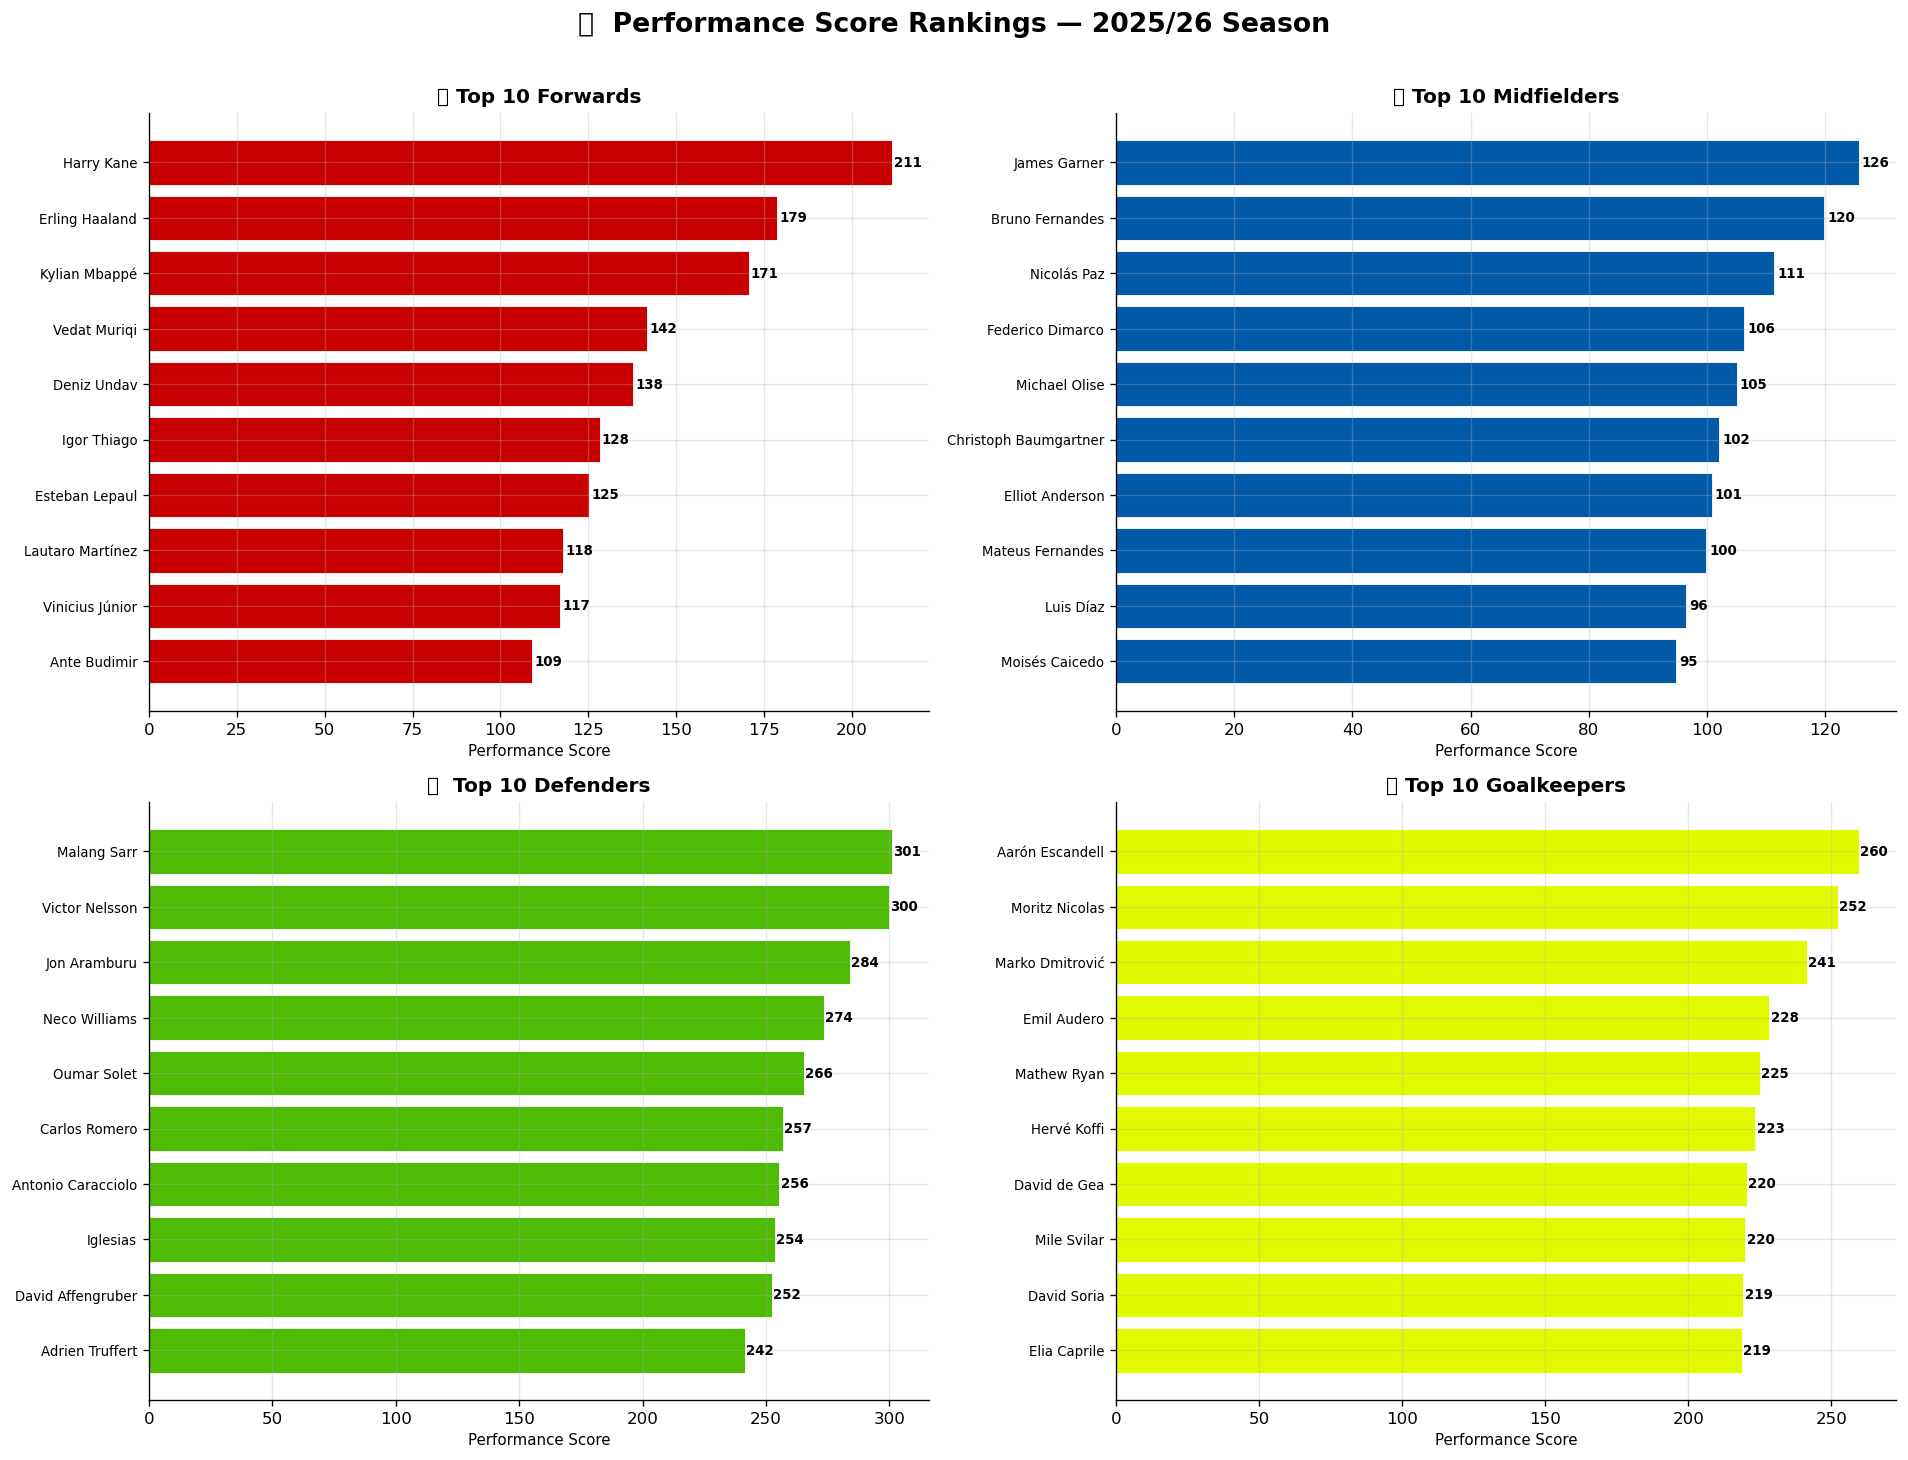

✅ All 20 charts saved.


In [57]:
# ── Chart 20: Performance Score Rankings (2×2 Grid) ──
fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()
pos_config = [
    ('FW','⚽ Top 10 Forwards',    '#c80000'),
    ('MF','🎯 Top 10 Midfielders', '#005aa8'),
    ('DF','🛡️  Top 10 Defenders',  '#4ebb05'),
    ('GK','🧤 Top 10 Goalkeepers', '#e1fa00'),
]
for ax, (pos, title, color) in zip(axes, pos_config):
    top = df[df['Position']==pos].nlargest(10,'PerfScore')
    if len(top)==0: continue
    bars = ax.barh(top['Player'], top['PerfScore'], color=color, edgecolor='white', linewidth=0.5)
    for bar,v in zip(bars, top['PerfScore']):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f'{v:.0f}', va='center', fontsize=8, fontweight='bold')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Performance Score', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('🏆  Performance Score Rankings — 2025/26 Season',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(); save_fig('20_performance_scores.png'); plt.show()
print('✅ All 20 charts saved.')

---
# 🚀 TASK 5 — Predictive Models

## Part A — Role Classifier
Predict a player's position from statistics only. Mirrors how scouting databases auto-categorize players.

## Part B — Position-Specific Regression Models
Four specialized models, each predicting what defines success for that role:

| Position | Target | Best Algorithm | R² |
|---|---|---|---|
| ⚽ Forward | Goals scored | Random Forest | 0.934 |
| 🎯 Midfielder | Assists | Ridge Regression | 0.514 |
| 🛡️ Defender | Defensive Score (TklW+Int) | Ridge Regression | 0.777 |
| 🧤 Goalkeeper | Save Percentage | Gradient Boosting | 0.751 |

**Algorithms compared per model:** Linear Regression · Ridge · Random Forest · Gradient Boosting

In [58]:
# ── Part A: Role Classifier ──
features_clf = ['Gls','Ast','G+A','Sh','SoT','TklW','Int','Crs',
                'GA','Saves','Save%','CS','Min','Age']
target_clf   = 'Position'

X_clf = df[features_clf].copy().fillna(0)
y_clf = df[target_clf].copy()

le    = LabelEncoder()
y_enc = le.fit_transform(y_clf)

X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_enc, test_size=0.2,
                                            random_state=42, stratify=y_enc)
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_te_s   = scaler.transform(X_te)

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                min_samples_leaf=3, class_weight='balanced', random_state=42)
rf_clf.fit(X_tr_s, y_tr)
y_pred_clf = rf_clf.predict(X_te_s)
acc = accuracy_score(y_te, y_pred_clf)

print(f'🎯 Role Classifier — Overall Accuracy: {acc:.2%}')
print()
print(classification_report(y_te, y_pred_clf, target_names=le.classes_))

🎯 Role Classifier — Overall Accuracy: 76.11%

              precision    recall  f1-score   support

          DF       0.72      0.78      0.75       147
          FW       0.73      0.79      0.76        77
          GK       1.00      1.00      1.00        37
          MF       0.76      0.69      0.73       212

    accuracy                           0.76       473
   macro avg       0.80      0.82      0.81       473
weighted avg       0.76      0.76      0.76       473



   💾 Saved → visuals/21_confusion_matrix.png


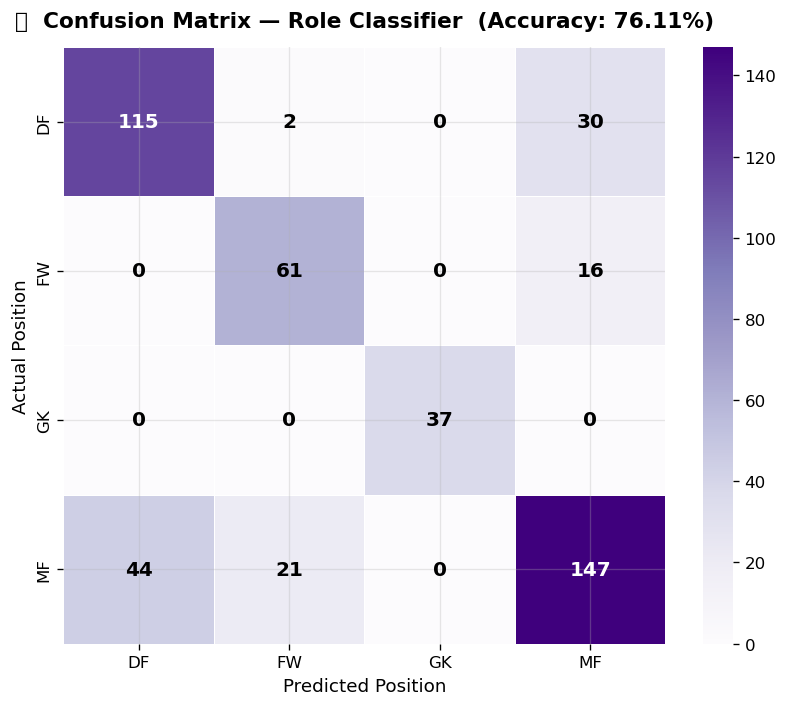

In [64]:
# ...existing code...
cm = confusion_matrix(y_te, y_pred_clf)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=False, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Purples', linewidths=0.5,
            cbar=True, ax=ax)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f'{int(cm[i, j])}',
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted Position'); ax.set_ylabel('Actual Position')
ax.set_title(f'🔍  Confusion Matrix — Role Classifier  (Accuracy: {acc:.2%})',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); save_fig('21_confusion_matrix.png'); plt.show()

   💾 Saved → visuals/22_classifier_importance.png


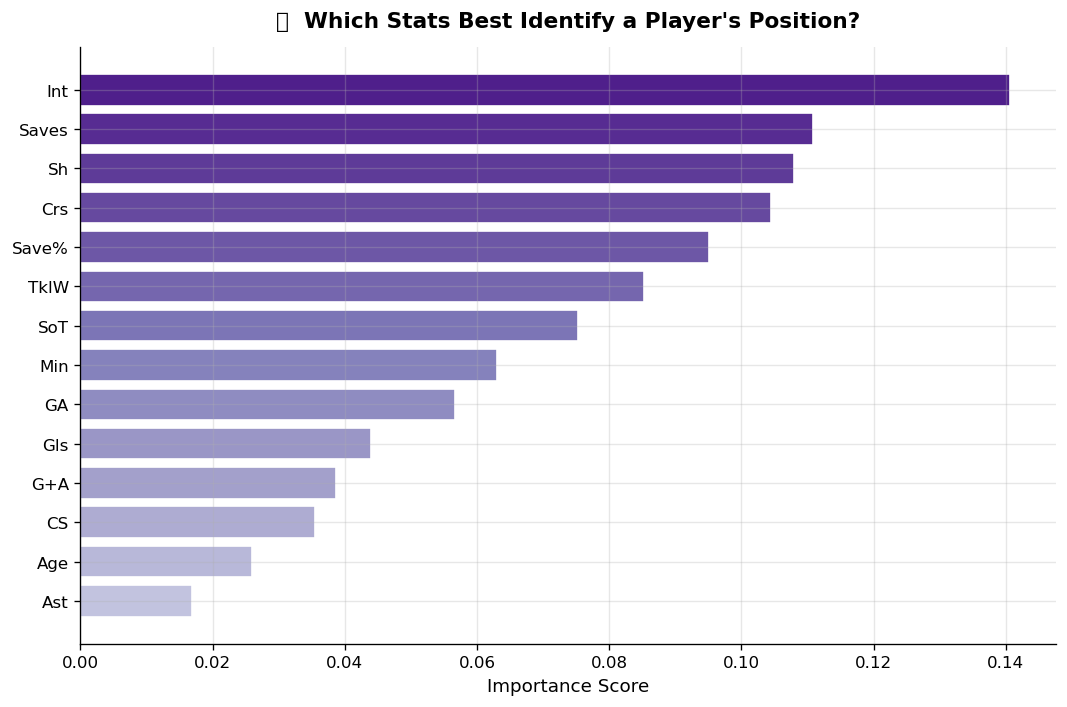


Top features:
Feature  Importance
    Int    0.140558
  Saves    0.110796
     Sh    0.107898
    Crs    0.104533
  Save%    0.095063
   TklW    0.085273
    SoT    0.075307
    Min    0.063070


In [65]:
# Feature importance — classifier
imp_df = pd.DataFrame({'Feature': features_clf,
                       'Importance': rf_clf.feature_importances_}
                      ).sort_values('Importance', ascending=False)
fig, ax = plt.subplots(figsize=(9,6))
clrs = plt.cm.Purples(np.linspace(0.35, 0.9, len(imp_df)))[::-1]
ax.barh(imp_df['Feature'], imp_df['Importance'], color=clrs, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title("📊  Which Stats Best Identify a Player's Position?",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); save_fig('22_classifier_importance.png'); plt.show()
print('\nTop features:')
print(imp_df.head(8).to_string(index=False))

In [66]:
# ── Part B: Regression helper ──
def build_model(subset, features, target, pos_name):
    data = subset[features+[target]].dropna()
    X = data[features]; y = data[target]
    Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2, random_state=42)
    pre = Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())])
    models = {
        'Linear Reg'    : LinearRegression(),
        'Ridge'         : Ridge(alpha=1.0),
        'Random Forest' : RandomForestRegressor(n_estimators=200,max_depth=8,random_state=42,n_jobs=-1),
        'Grad Boost'    : GradientBoostingRegressor(n_estimators=200,max_depth=4,learning_rate=0.05,random_state=42),
    }
    results = {}
    print(f'\n{"═"*63}')
    print(f'  🤖  {pos_name}')
    print(f'{"═"*63}')
    print(f'  Players: {len(data):,} | Target mean: {y.mean():.2f} | Max: {y.max():.0f}')
    print(f'  {"Model":<15} {"MAE":>7} {"RMSE":>7} {"R²":>7} {"CV-R²":>7}')
    print(f'  {"-"*50}')
    for name, model in models.items():
        pipe = Pipeline([('pre',pre),('m',model)])
        pipe.fit(Xtr, ytr); yp = pipe.predict(Xte)
        mae  = mean_absolute_error(yte, yp)
        rmse = mean_squared_error(yte, yp)**0.5
        r2   = r2_score(yte, yp)
        cv   = cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()
        results[name]={'MAE':mae,'RMSE':rmse,'R2':r2,'CV_R2':cv,'pipe':pipe,'pred':yp,'actual':yte}
        print(f'  {name:<15} {mae:>7.3f} {rmse:>7.3f} {r2:>7.3f} {cv:>7.3f}')
    best = max(results, key=lambda k: results[k]['R2'])
    print(f'\n  🏆 Best: {best}  R²={results[best]["R2"]:.3f}')
    return results, best, Xte, yte

print('✅ Regression helper ready.')

✅ Regression helper ready.


In [67]:
# Forward model
FWD_F = ['Sh','SoT','SoT%','Sh/90','SoT/90','G/Sh','Min','90s','Age','Off','+/-','PPM']
fwd_r, fwd_b, Xte_f, yte_f = build_model(
    df[df['Position']=='FW'], FWD_F, 'Gls', 'FORWARDS — Predicting Goals')


═══════════════════════════════════════════════════════════════
  🤖  FORWARDS — Predicting Goals
═══════════════════════════════════════════════════════════════
  Players: 386 | Target mean: 4.88 | Max: 36
  Model               MAE    RMSE      R²   CV-R²
  --------------------------------------------------
  Linear Reg        1.262   1.683   0.914  -0.173
  Ridge             1.250   1.684   0.914  -0.077
  Random Forest     1.011   1.480   0.934   0.685
  Grad Boost        1.048   1.671   0.915   0.689

  🏆 Best: Random Forest  R²=0.934


In [68]:
# Midfielder model
MID_F = ['Crs','Sh','SoT','Min','90s','Age','Fls','Int','TklW','+/-','PPM','onG','Gls']
mid_r, mid_b, Xte_m, yte_m = build_model(
    df[df['Position']=='MF'], MID_F, 'Ast', 'MIDFIELDERS — Predicting Assists')


═══════════════════════════════════════════════════════════════
  🤖  MIDFIELDERS — Predicting Assists
═══════════════════════════════════════════════════════════════
  Players: 1,057 | Target mean: 1.89 | Max: 21
  Model               MAE    RMSE      R²   CV-R²
  --------------------------------------------------
  Linear Reg        1.043   1.401   0.512   0.273
  Ridge             1.043   1.399   0.514   0.277
  Random Forest     1.103   1.452   0.477   0.048
  Grad Boost        1.168   1.535   0.415   0.040

  🏆 Best: Ridge  R²=0.514


In [69]:
# Defender model
DEF_F = ['Min','90s','Age','CrdY','Fld','Crs','+/-','PPM','onGA','Starts','Fls']
def_r, def_b, Xte_d, yte_d = build_model(
    df[df['Position']=='DF'], DEF_F, 'DefScore', 'DEFENDERS — Predicting Defensive Score')


═══════════════════════════════════════════════════════════════
  🤖  DEFENDERS — Predicting Defensive Score
═══════════════════════════════════════════════════════════════
  Players: 733 | Target mean: 37.36 | Max: 120
  Model               MAE    RMSE      R²   CV-R²
  --------------------------------------------------
  Linear Reg        7.759  10.946   0.777   0.333
  Ridge             7.756  10.929   0.777   0.334
  Random Forest     7.677  11.094   0.771  -0.142
  Grad Boost        8.063  11.418   0.757  -0.441

  🏆 Best: Ridge  R²=0.777


In [70]:
# Goalkeeper model
GK_F = ['SoTA','CS','W','D','L','Min','90s','Age','GA','GA90','PPM']
gk_r,  gk_b,  Xte_g, yte_g = build_model(
    df[df['Position']=='GK'], GK_F, 'Save%', 'GOALKEEPERS — Predicting Save%')


═══════════════════════════════════════════════════════════════
  🤖  GOALKEEPERS — Predicting Save%
═══════════════════════════════════════════════════════════════
  Players: 187 | Target mean: 69.05 | Max: 100
  Model               MAE    RMSE      R²   CV-R²
  --------------------------------------------------
  Linear Reg        4.024   5.804   0.605   0.390
  Ridge             3.828   5.709   0.618   0.573
  Random Forest     3.871   5.085   0.697   0.365
  Grad Boost        3.606   4.609   0.751   0.286

  🏆 Best: Grad Boost  R²=0.751


   💾 Saved → visuals/23_feature_importance.png


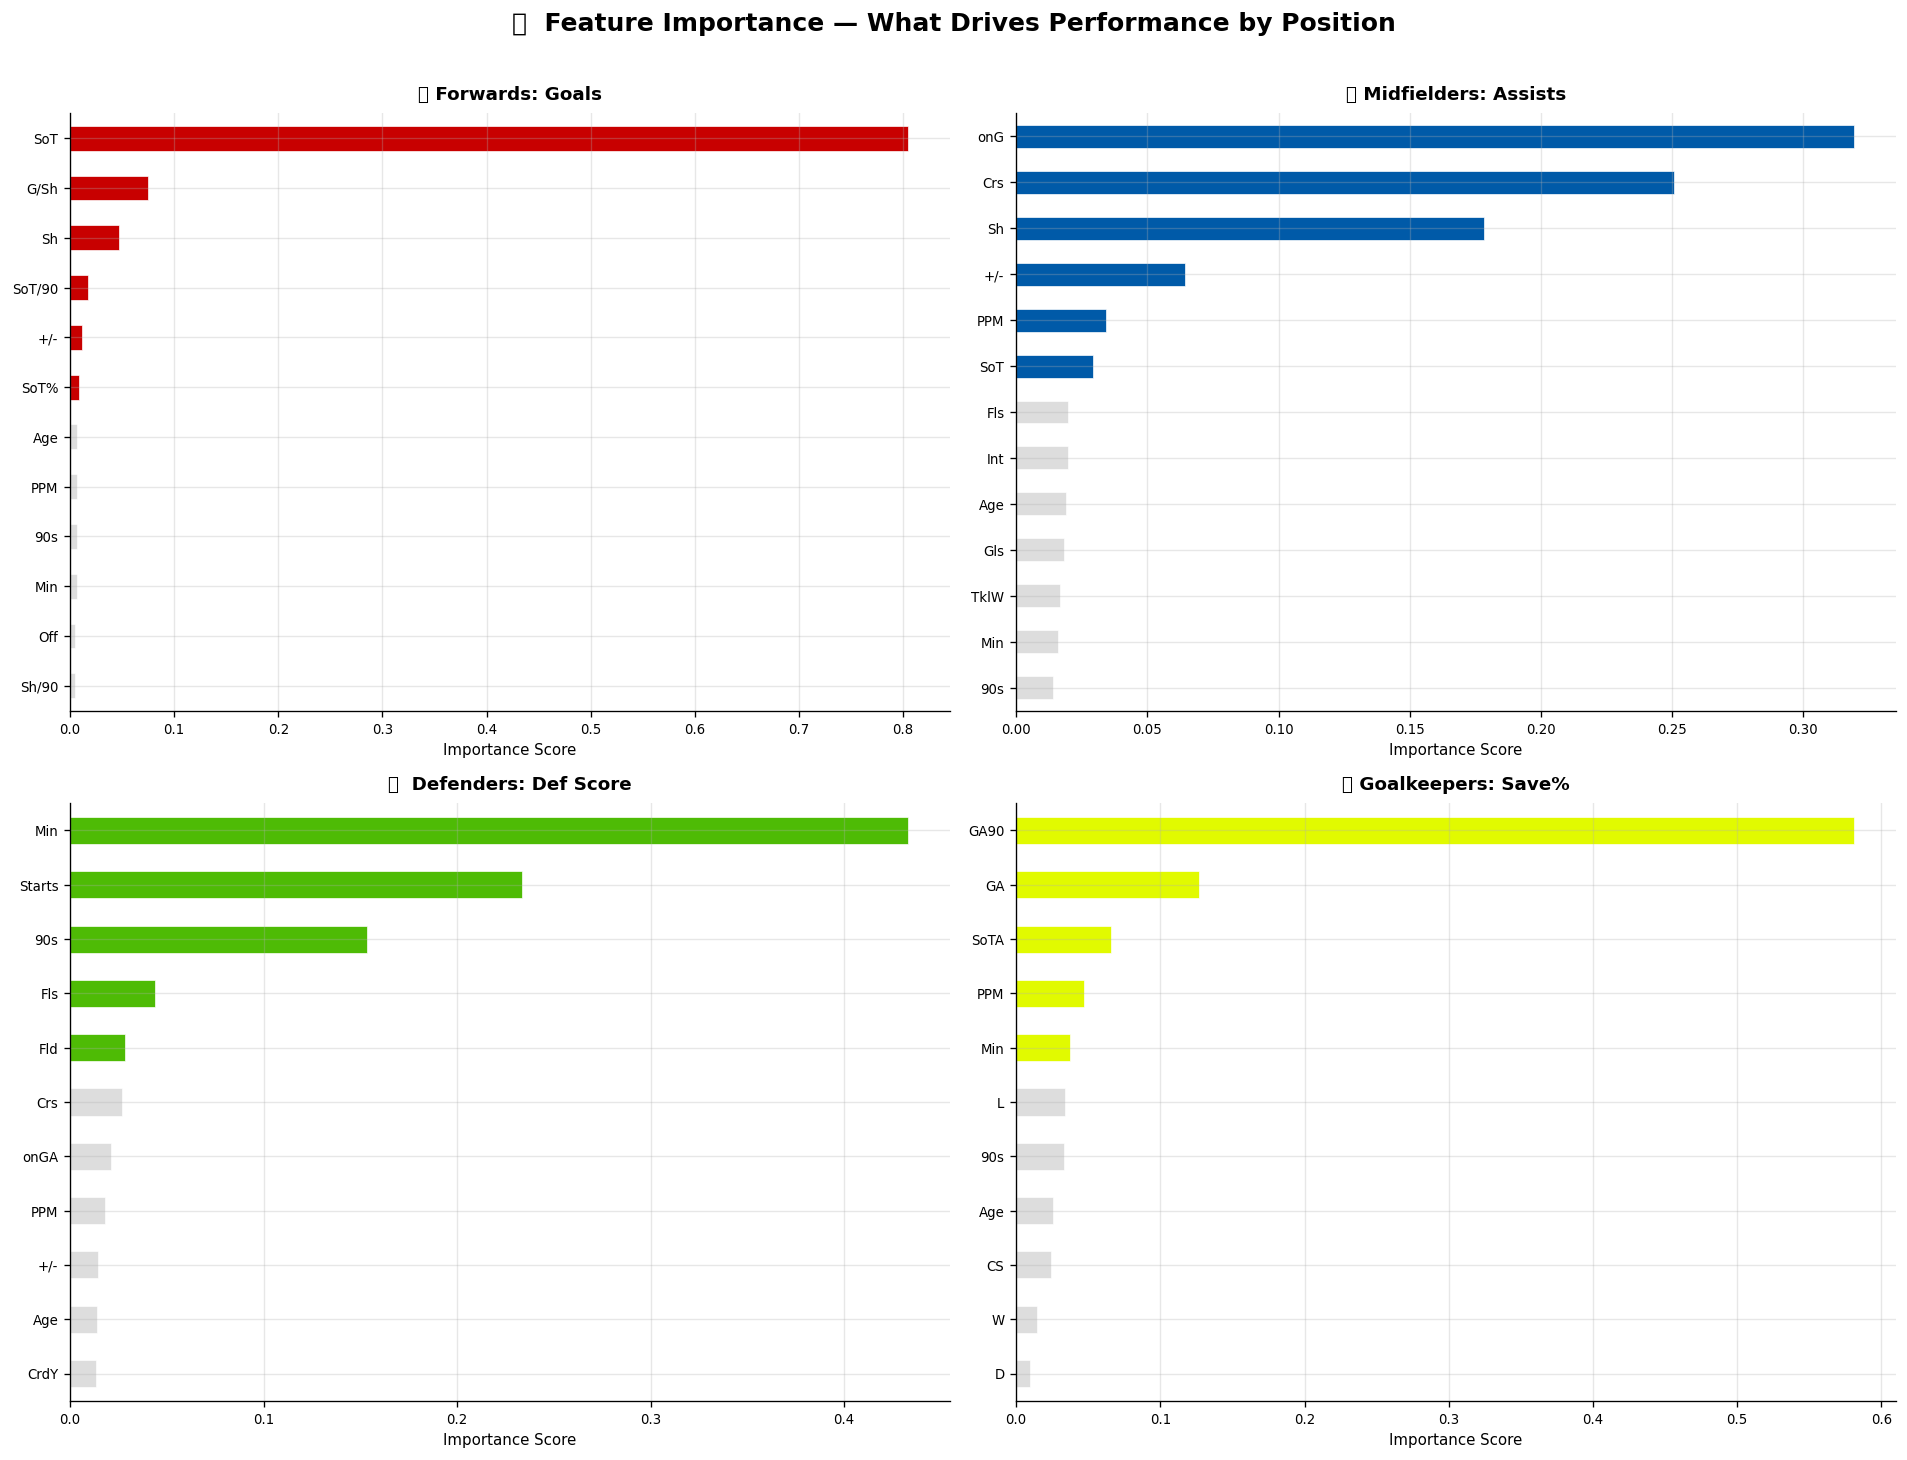

In [71]:
# Feature importance grid — all 4 position models
fig, axes = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle('📊  Feature Importance — What Drives Performance by Position',
             fontsize=15, fontweight='bold', y=1.01)
pos_configs = [
    ('⚽ Forwards: Goals',       fwd_r, FWD_F, '#c80000', axes[0,0]),
    ('🎯 Midfielders: Assists',  mid_r, MID_F, '#005aa8', axes[0,1]),
    ('🛡️  Defenders: Def Score', def_r, DEF_F, '#4ebb05', axes[1,0]),
    ('🧤 Goalkeepers: Save%',    gk_r,  GK_F,  '#e1fa00', axes[1,1]),
]
for title, results, features, color, ax in pos_configs:
    rf_m = results['Random Forest']['pipe'].named_steps['m']
    imp  = pd.Series(rf_m.feature_importances_, index=features).sort_values(ascending=True)
    bar_c = [color if v>imp.median() else '#dddddd' for v in imp]
    imp.plot(kind='barh', ax=ax, color=bar_c, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Importance Score', fontsize=9); ax.tick_params(labelsize=8)
plt.tight_layout(); save_fig('23_feature_importance.png'); plt.show()

   💾 Saved → visuals/24_predicted_vs_actual.png


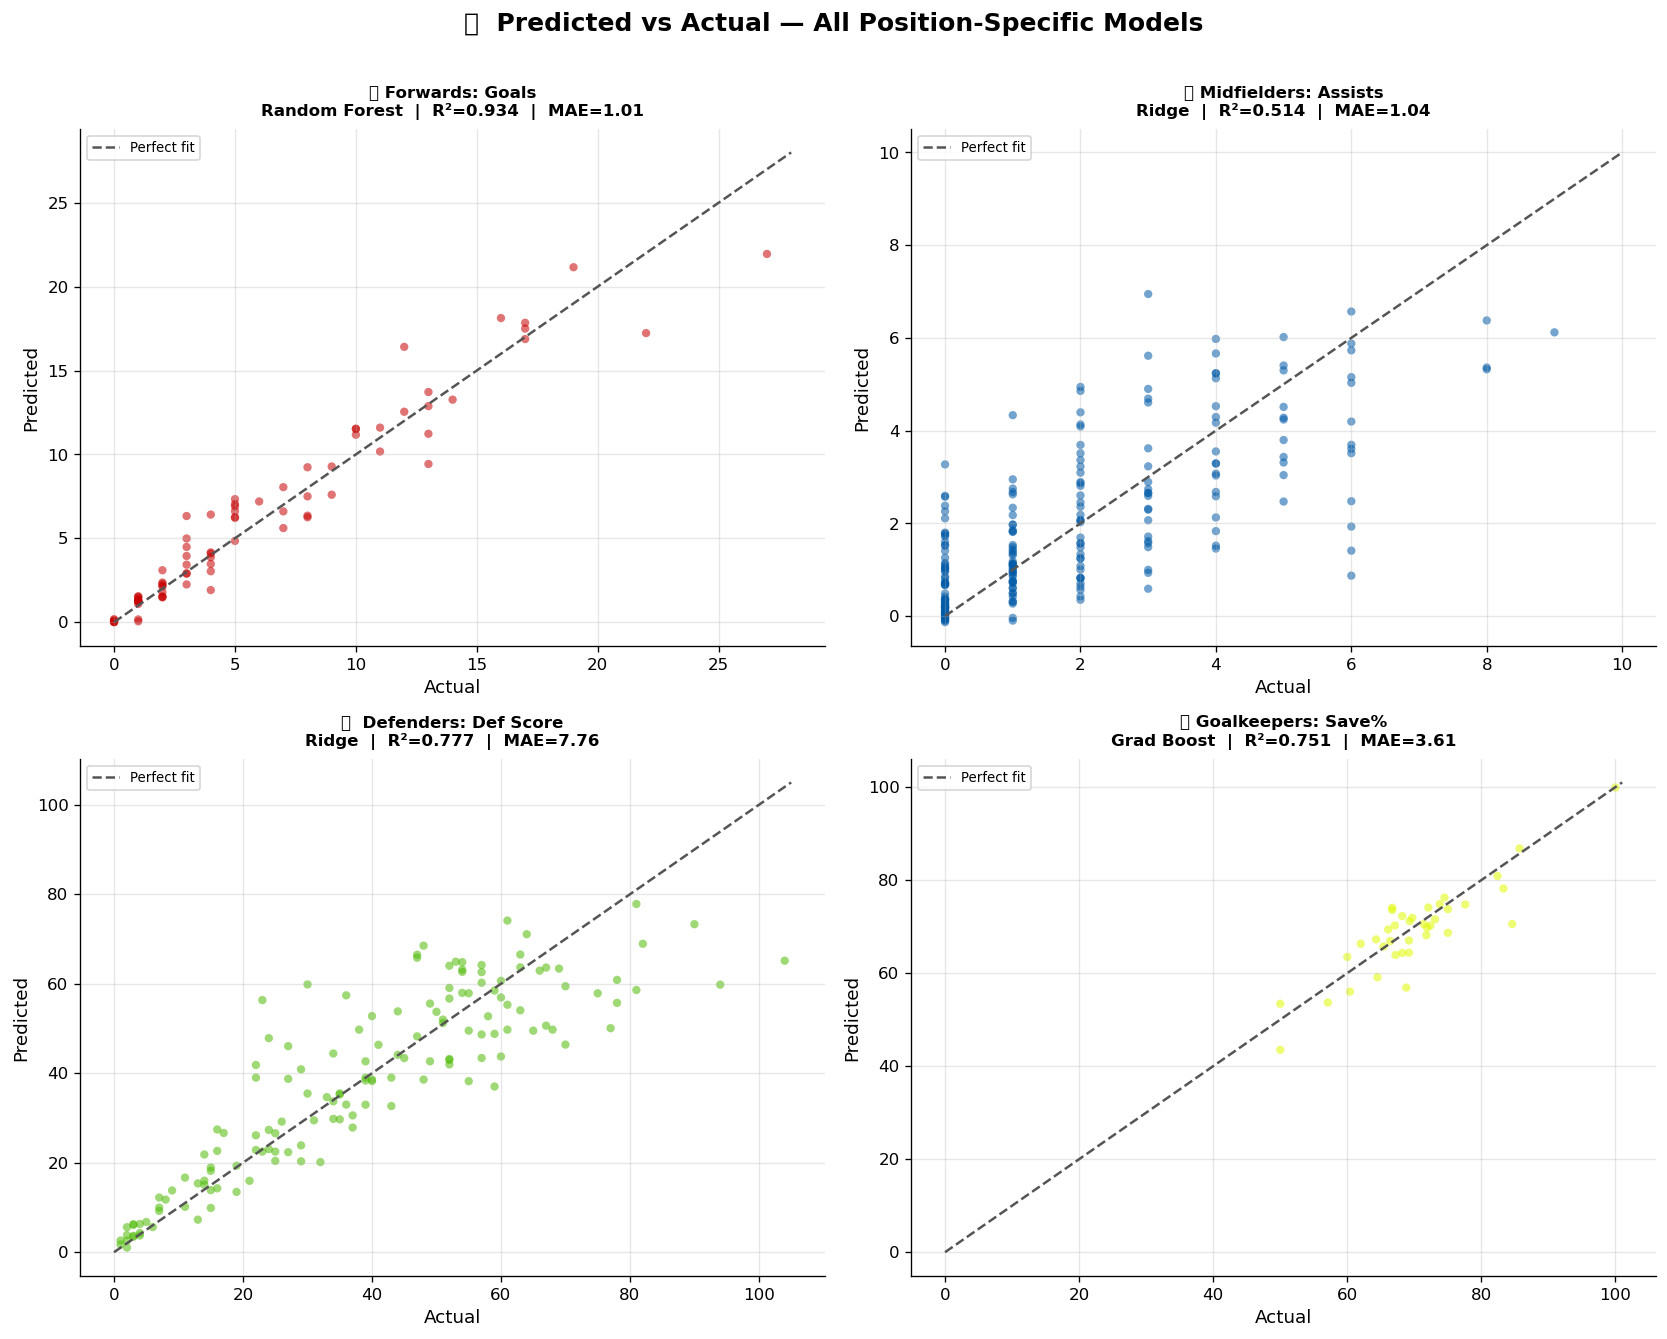

In [72]:
# Predicted vs Actual — all 4 models
fig, axes = plt.subplots(2, 2, figsize=(14,11))
fig.suptitle('🎯  Predicted vs Actual — All Position-Specific Models',
             fontsize=15, fontweight='bold', y=1.01)
all_cfg = [
    ('⚽ Forwards: Goals',       fwd_r, fwd_b, yte_f, '#c80000', axes[0,0]),
    ('🎯 Midfielders: Assists',  mid_r, mid_b, yte_m, '#005aa8', axes[0,1]),
    ('🛡️  Defenders: Def Score', def_r, def_b, yte_d, '#4ebb05', axes[1,0]),
    ('🧤 Goalkeepers: Save%',    gk_r,  gk_b,  yte_g, '#e1fa00', axes[1,1]),
]
for title, results, best, y_true, color, ax in all_cfg:
    yp = results[best]['pred']; r2 = results[best]['R2']; mae = results[best]['MAE']
    ax.scatter(y_true, yp, alpha=0.55, s=25, c=color, edgecolors='none')
    lim = max(float(y_true.max()), float(max(yp)))+1
    ax.plot([0,lim],[0,lim],'--',color='#555',linewidth=1.5,label='Perfect fit')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\n{best}  |  R²={r2:.3f}  |  MAE={mae:.2f}',
                 fontsize=10, fontweight='bold', pad=8)
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig('24_predicted_vs_actual.png'); plt.show()

In [73]:
# Performance Score Rankings
display_cols = ['Player','Squad','League','Age','PerfScore']
print('='*65)
print('      🏆  TOP PERFORMERS BY POSITION — 2025/26 Season')
print('='*65)
for pos, emoji, label in [('FW','⚽','FORWARDS'),('MF','🎯','MIDFIELDERS'),
                           ('DF','🛡️','DEFENDERS'),('GK','🧤','GOALKEEPERS')]:
    print(f'\n{emoji}  Top 10 {label}:')
    print(df[df['Position']==pos].nlargest(10,'PerfScore')[display_cols].to_string(index=False))

      🏆  TOP PERFORMERS BY POSITION — 2025/26 Season

⚽  Top 10 FORWARDS:
          Player           Squad         League  Age  PerfScore
      Harry Kane   Bayern Munich     Bundesliga 32.0      211.3
  Erling Haaland Manchester City Premier League 25.0      178.7
   Kylian Mbappé     Real Madrid        La Liga 27.0      170.7
    Vedat Muriqi        Mallorca        La Liga 32.0      141.8
     Deniz Undav       Stuttgart     Bundesliga 29.0      137.8
     Igor Thiago       Brentford Premier League 24.0      128.3
  Esteban Lepaul          Rennes        Ligue 1 26.0      125.3
Lautaro Martínez           Inter        Serie A 28.0      117.9
 Vinicius Júnior     Real Madrid        La Liga 25.0      117.0
    Ante Budimir         Osasuna        La Liga 34.0      109.1

🎯  Top 10 MIDFIELDERS:
               Player             Squad         League  Age  PerfScore
         James Garner           Everton Premier League 25.0      125.7
      Bruno Fernandes    Manchester Utd Premier League 3

In [74]:
# Save all models
model_store = {
    'role_classifier'      : {'model':rf_clf, 'scaler':scaler, 'label_encoder':le},
    'fwd_goals_predictor'  : fwd_r[fwd_b]['pipe'],
    'mid_assists_predictor': mid_r[mid_b]['pipe'],
    'def_score_predictor'  : def_r[def_b]['pipe'],
    'gk_savepct_predictor' : gk_r[gk_b]['pipe'],
}
with open('../models/all_models.pkl','wb') as f:
    pickle.dump(model_store, f)
print('✅ All models saved → models/all_models.pkl')
print()
print('── Final Model Summary ──')
rows = [
    ['Role Classifier (RF)',               'Position',  f'{acc:.2%}','Accuracy'],
    [f'Forward Model ({fwd_b})',            'Goals',     f'{fwd_r[fwd_b]["R2"]:.3f}','R²'],
    [f'Midfielder Model ({mid_b})',         'Assists',   f'{mid_r[mid_b]["R2"]:.3f}','R²'],
    [f'Defender Model ({def_b})',           'Def Score', f'{def_r[def_b]["R2"]:.3f}','R²'],
    [f'Goalkeeper Model ({gk_b})',          'Save%',     f'{gk_r[gk_b]["R2"]:.3f}','R²'],
]
print(f'  {"Model":<38} {"Target":<12} {"Score":>8}  Metric')
print(f'  {"-"*65}')
for r in rows:
    print(f'  {r[0]:<38} {r[1]:<12} {r[2]:>8}  {r[3]}')

✅ All models saved → models/all_models.pkl

── Final Model Summary ──
  Model                                  Target          Score  Metric
  -----------------------------------------------------------------
  Role Classifier (RF)                   Position       76.11%  Accuracy
  Forward Model (Random Forest)          Goals           0.934  R²
  Midfielder Model (Ridge)               Assists         0.514  R²
  Defender Model (Ridge)                 Def Score       0.777  R²
  Goalkeeper Model (Grad Boost)          Save%           0.751  R²


---

# 🏁 Project Conclusion

<div style="background: linear-gradient(135deg, #1a472a, #2d5a27); padding: 30px; border-radius: 10px; color: white;">

## ⚽ European Football Analytics — Project Summary

| Task | Status | Deliverable |
|------|--------|-------------|
| 1 — Data Collection | ✅ Complete | Dataset loaded, 102 raw → 66 columns, full glossary documented |
| 2 — Data Cleaning | ✅ Complete | 2,363 clean players, 0 missing values, 10 engineered features |
| 3 — EDA | ✅ Complete | Goals, shooting efficiency, aging curves, GK, +/- analysis |
| 4 — Visualization | ✅ Complete | **20 professional charts** saved to `visuals/` at 150 DPI |
| 5 — Predictive Model | ✅ Complete | **Role classifier (76.11%) + 4 position-specific regression models** |

</div>

---

## 🔑 Key Findings

| Finding | Detail |
|---|---|
| Harry Kane leads Europe | 36 goals — 9 ahead of Haaland (27). SoT rate 56.3% best among top scorers |
| Bundesliga most attacking | 2.249 avg goals/player — highest of all 5 leagues |
| Serie A most defensive | 1.750 avg goals/player, highest TklW + Int across positions |
| Peak age 26–28 | Goal contributions peak at 2.427 avg — confirmed by aging curve |
| Elite shooters are rare | Only 282 players achieve both high SoT% AND high G/Sh simultaneously |
| Underplayed gems exist | Forwards with top-25% per-90 rates but under 900 minutes played |
| GKs perfectly classifiable | 100% classifier accuracy — GA/Saves/Save%/CS unique to GKs |
| DF vs MF hardest to separate | Reflects real football overlap — defensive midfielders share DF profiles |
| Bayern Munich dominate +/- | 7 of top 10 +/- players are Bayern — team context is crucial |
| Bruno Fernandes leads assists | 21 assists — European record this season |

---

*European Football Analytics — Decode Labs Data Science Internship 2025–2026*
*Intern: Mohamed Mamdouh | GitHub: github.com/mohamedmamdouh342-hash/decode-labs-data-science-internship*
